# <span style="color: red;">  **BUSINESS CASE:** **REMAINING USEFUL LIFE PREDICTION OF TURBOFAN ENGINE FOR PREDICTIVE MAINTENANCE USING AI-ENABLED PROGNOSTICS** </span>


In [1]:
## Import Necessary Library
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
import joblib

# To display all features
pd.set_option("display.max_columns", None)

In [ ]:
## Load Data
df = pd.read_csv("/content/train_FD001.txt", delim_whitespace=True, header=None)
df.head()

<ipython-input-2-30d1387a641a>:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("/content/train_FD001.txt", delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
## Assigning column names
column_name = ['Engine_ID', 'Cycle', 'Setting_1', 'Setting_2', 'Setting_3'] + [f"Sensor_{i}" for i in range(1,22)]
df.columns = column_name
df.head()

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
## Basic check of data
df.shape

(20631, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Engine_ID  20631 non-null  int64  
 1   Cycle      20631 non-null  int64  
 2   Setting_1  20631 non-null  float64
 3   Setting_2  20631 non-null  float64
 4   Setting_3  20631 non-null  float64
 5   Sensor_1   20631 non-null  float64
 6   Sensor_2   20631 non-null  float64
 7   Sensor_3   20631 non-null  float64
 8   Sensor_4   20631 non-null  float64
 9   Sensor_5   20631 non-null  float64
 10  Sensor_6   20631 non-null  float64
 11  Sensor_7   20631 non-null  float64
 12  Sensor_8   20631 non-null  float64
 13  Sensor_9   20631 non-null  float64
 14  Sensor_10  20631 non-null  float64
 15  Sensor_11  20631 non-null  float64
 16  Sensor_12  20631 non-null  float64
 17  Sensor_13  20631 non-null  float64
 18  Sensor_14  20631 non-null  float64
 19  Sensor_15  20631 non-null  float64
 20  Sensor

In [ ]:
df.describe()

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


**Observation:**
1. No missing value is present
2. No categorical data is available
3. Engine_ID is a unique feature and Sensor_3,Sensor_18, Sensor_19 features std is 0 means these feature is called as constant features so we can drop this features.
4. Three Operating setting and 21 sensor readings are available.
5. No target feature is available.


In [ ]:
""""
Domain Analysis of features

1. Engine ID: Unique identifier for each engine.
2. Cycle: Time step (Each row represents one cycle in engine operation).

Operating Conditions:
3. Setting_1: Operational setting (e.g., throttle position).
4. Setting_2: Operational setting (e.g., altitude).
5. Setting_3: Operational setting (e.g., Mach number).

Sensor Readings:
6. Sensor_1: Total temperature at fan inlet.
7. Sensor_2: Total temperature at LPC (Low-Pressure Compressor) outlet.
8. Sensor_3: Total temperature at HPC (High-Pressure Compressor) outlet.
9. Sensor_4: Total temperature at LPT (Low-Pressure Turbine) outlet.
10. Sensor_5: Pressure at fan inlet.
11. Sensor_6: Total pressure in bypass-duct.
12. Sensor_7: Total pressure at HPC outlet.
13. Sensor_8: Physical fan speed.
14. Sensor_9: Physical core speed.
15. Sensor_10: Engine pressure ratio (P50/P2).
16. Sensor_11: Static pressure at HPC outlet.
17. Sensor_12: Ratio of fuel flow to Ps30.
18. Sensor_13: Corrected fan speed.
19. Sensor_14: Corrected core speed.
20. Sensor_15: Bypass ratio.
21. Sensor_16: Burner fuel-air ratio.
22. Sensor_17: Bleed enthalpy.
23. Sensor_18: Demanded fan speed.
24. Sensor_19: Demanded corrected fan speed.
25. Sensor_20: HPT (High-Pressure Turbine) coolant bleed.
26. Sensor_21: LPT (Low-Pressure Turbine) coolant bleed.

"""
print()

## **Target Variable Creation**
### **Creation of Health Indicator**
* Create Non-Liner RUL formula that shows how things break down over time

              h(t) = 1+d-exp(a⋅t^b)

where:


* h(t) = Health indicator at cycle 𝑡 (ranges from 1 to 0).

* d = Initial degradation (small positive constant).

* t = Current cycle number.

* a and b = Tunable coefficients that control degradation rate.

##### **Calculation of alpha a?**
                alpha = log(1+d)/t_max

where:

* t max = Max cycle before failure for a given engine.

* This ensures ℎ(𝑡) = 0 at the final cycle.

### **Convert Health Indicator to RUL**

Scale h(t) to compute RUL:

                     RUL=h(t) x t_max






#### **Main Features**
* **Exponential Decay:** The function start chaning slowely at first but speed up as things get close to failure.
* **Start from non zero value:** unlike the simple formulas this allows early stage degradation modeling.
* **Changes smoothly untile breaking:** It ensures the gradual decline, which is more realistic than sudden drop.

In [ ]:
# Define function for RUL
def compute_rul(engine_data, d=0.1, b=1):
  """ Compute RUL using non liner formula:
         Parameters:
         - enigne_data: dataframe of single engine run to failure
         - d: initial degredation of engine.(set by default=0.05)
         - b: exponential coefficient.(set by default=0.8) """

  # max cycle i.e engine failure point
  max_cycle = engine_data["Cycle"].max()

  # calculate alpha base on formula: alpha = log(1+d)/t_max
  alpha = np.log(1 + d) / max_cycle

  # Calculate health index: h(t) = 1 + d - exp(a * t^b)
  engine_data["Health_index"] = 1 + d - np.exp(alpha * engine_data["Cycle"] ** b)

  # Conver health index to the rul. rul = h(t) * max_cycle
  engine_data['RUL'] = engine_data['Health_index'] * max_cycle

  # Check rul value are non negative
  engine_data["RUL"] =  engine_data["RUL"].clip(lower=0)

  return engine_data






In [ ]:
## Apply RUL calculation for each engine
data = df.groupby("Engine_ID").apply(lambda x: compute_rul(x, d=0.1, b=1)).reset_index(drop=True)

## Save preprocess data
data.to_csv("preprocess_fd001.csv", index=False)

<ipython-input-9-10ab470ad48b>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = df.groupby("Engine_ID").apply(lambda x: compute_rul(x, d=0.1, b=1)).reset_index(drop=True)


In [ ]:
## Read preprocess data
data = pd.read_csv("preprocess_fd001.csv")
data.head()

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Health_index,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.099503,19.104666
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.099007,19.009285
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.098510,18.913856
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.098012,18.818381
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.097515,18.722857


In [ ]:
# get min and max RUL
print(f"Minimum:{min(data.RUL)}")
print(f"Maximum:{max(data.RUL)}")

Minimum:0.0
Maximum:36.1046772720912


## **Explotary Data Analysis**
**Univariate Analysis**

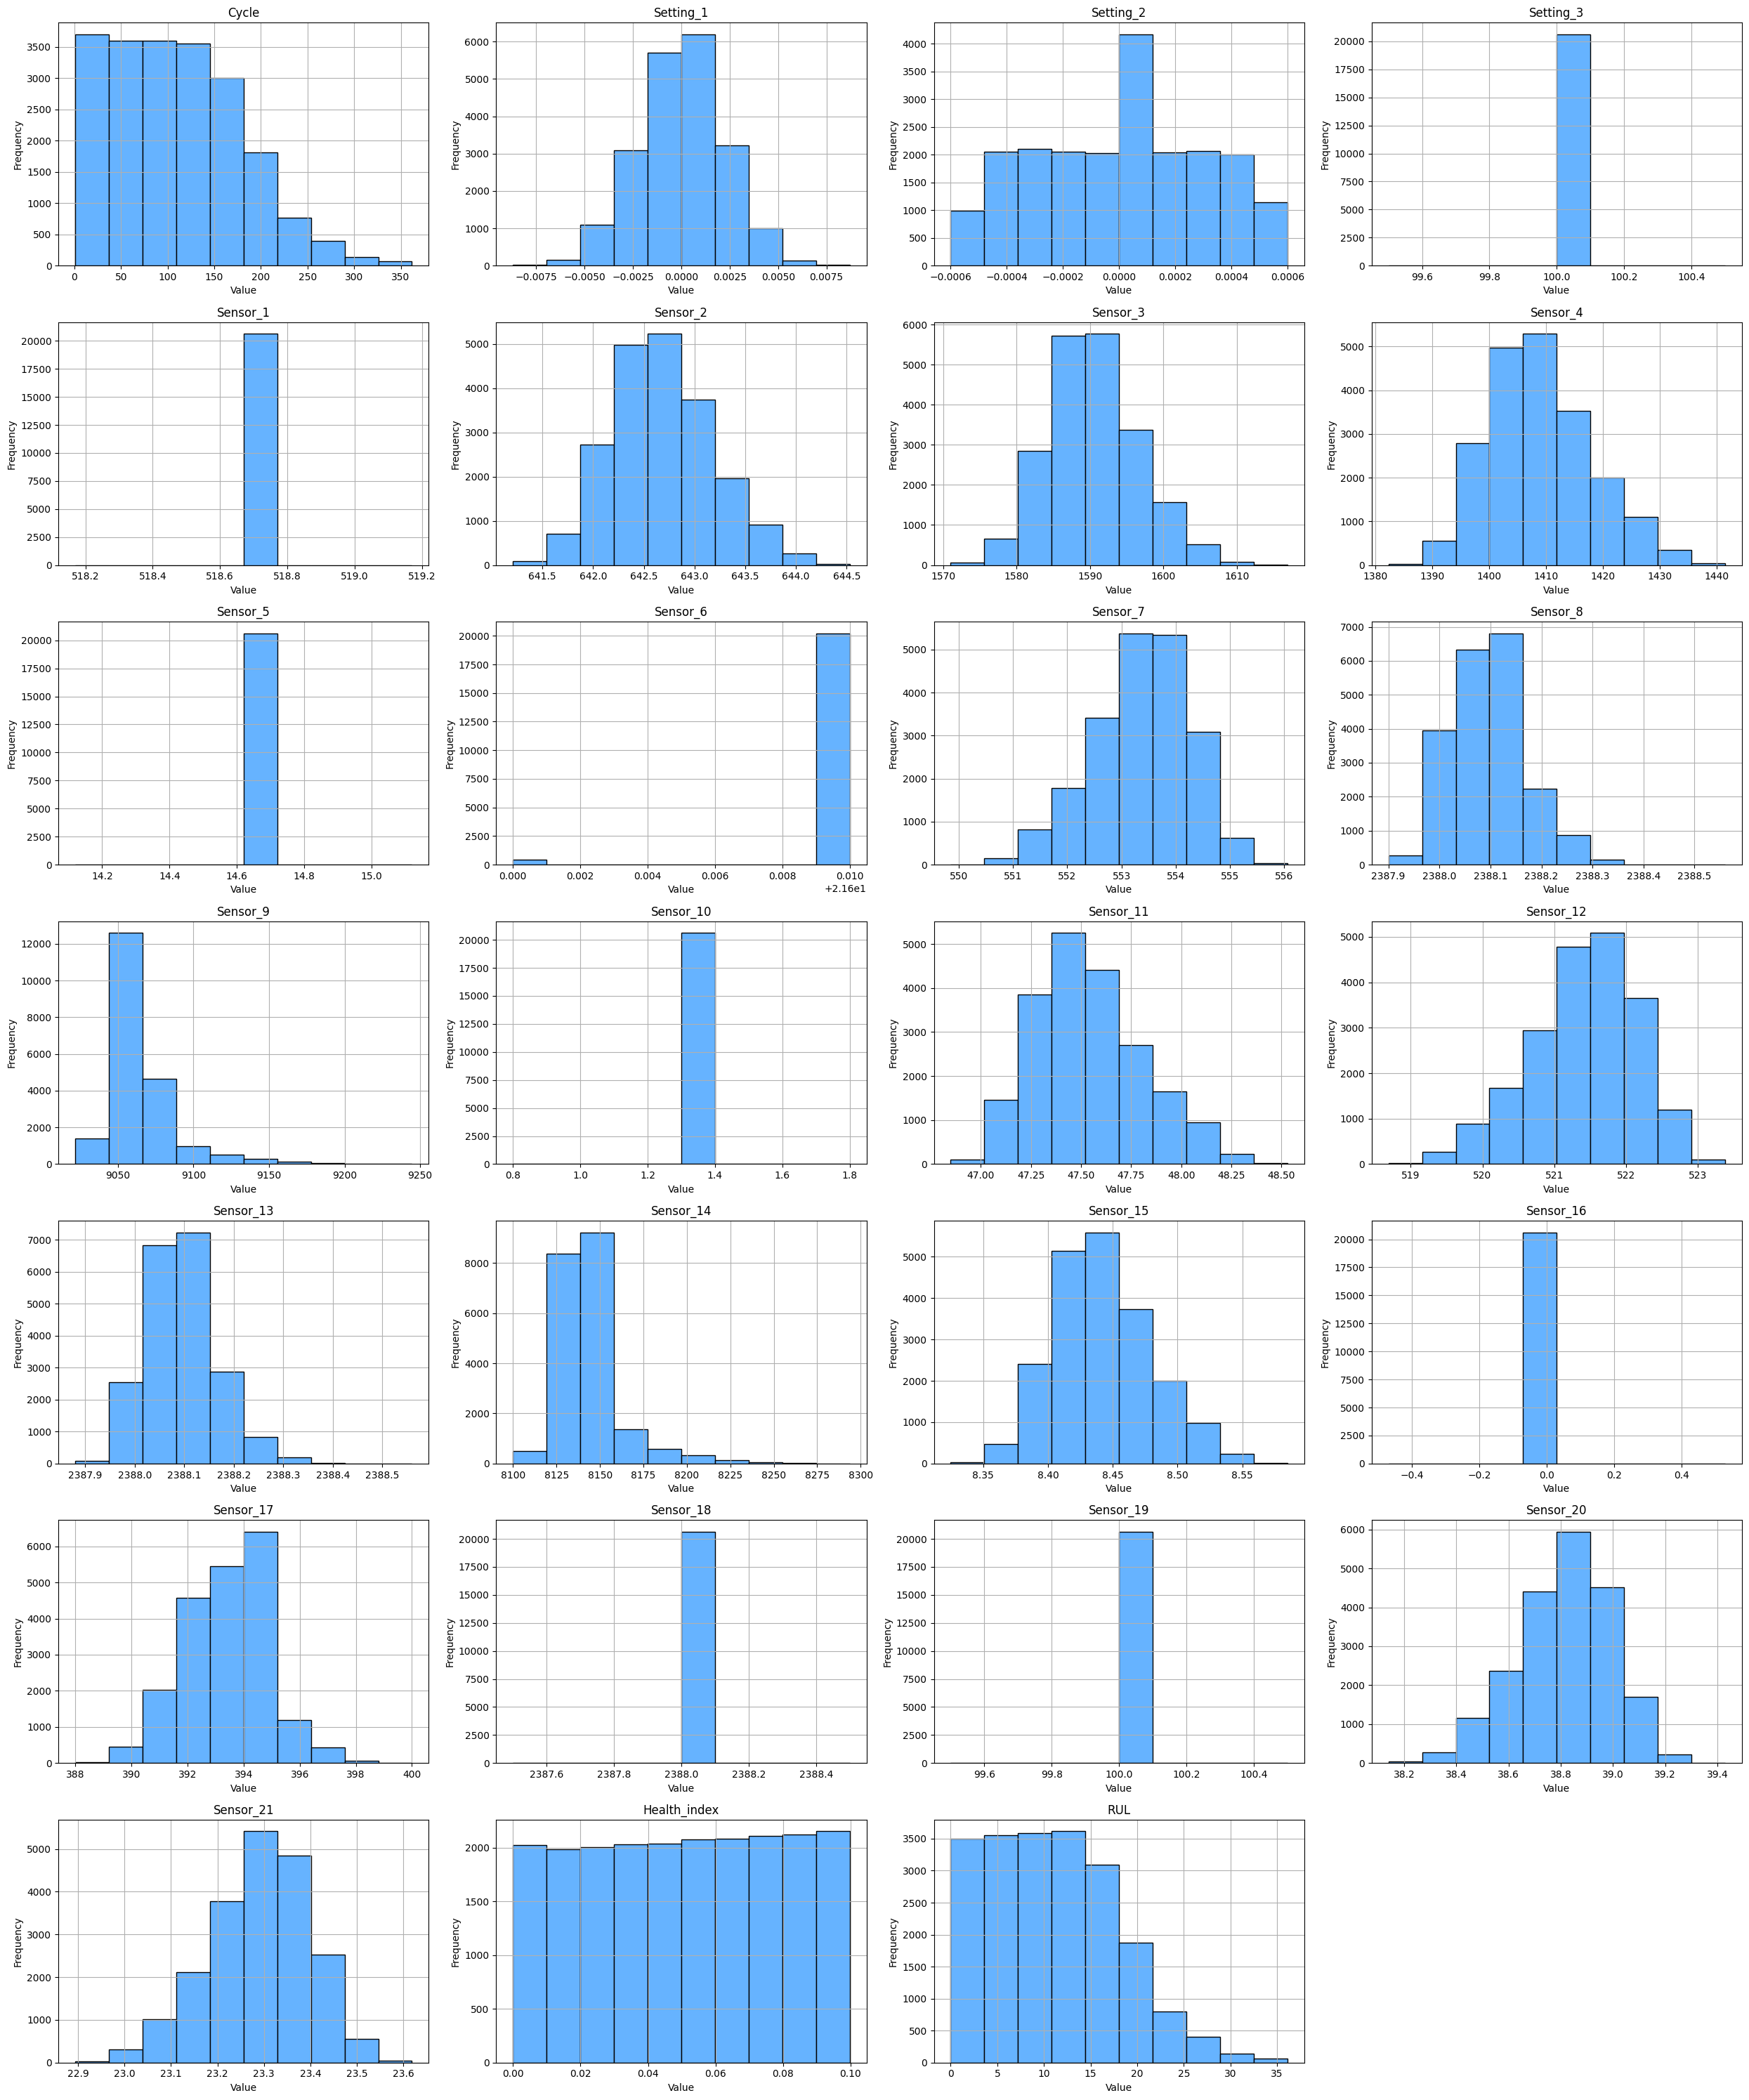

In [ ]:
# Check distribution of all features
columns = data.iloc[:,1:]
plt.figure(figsize=(25,30))
plotno = 1  # Counter
for column in columns:
  if plotno < 30:
    plt.subplot(7,4,plotno)
    plt.hist(data[column], color='#66b3ff', edgecolor='black')
    plt.title(column)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid()
  plotno+=1
plt.tight_layout()
plt.show()

**Bivariate Analysis With Respect to the RUL**

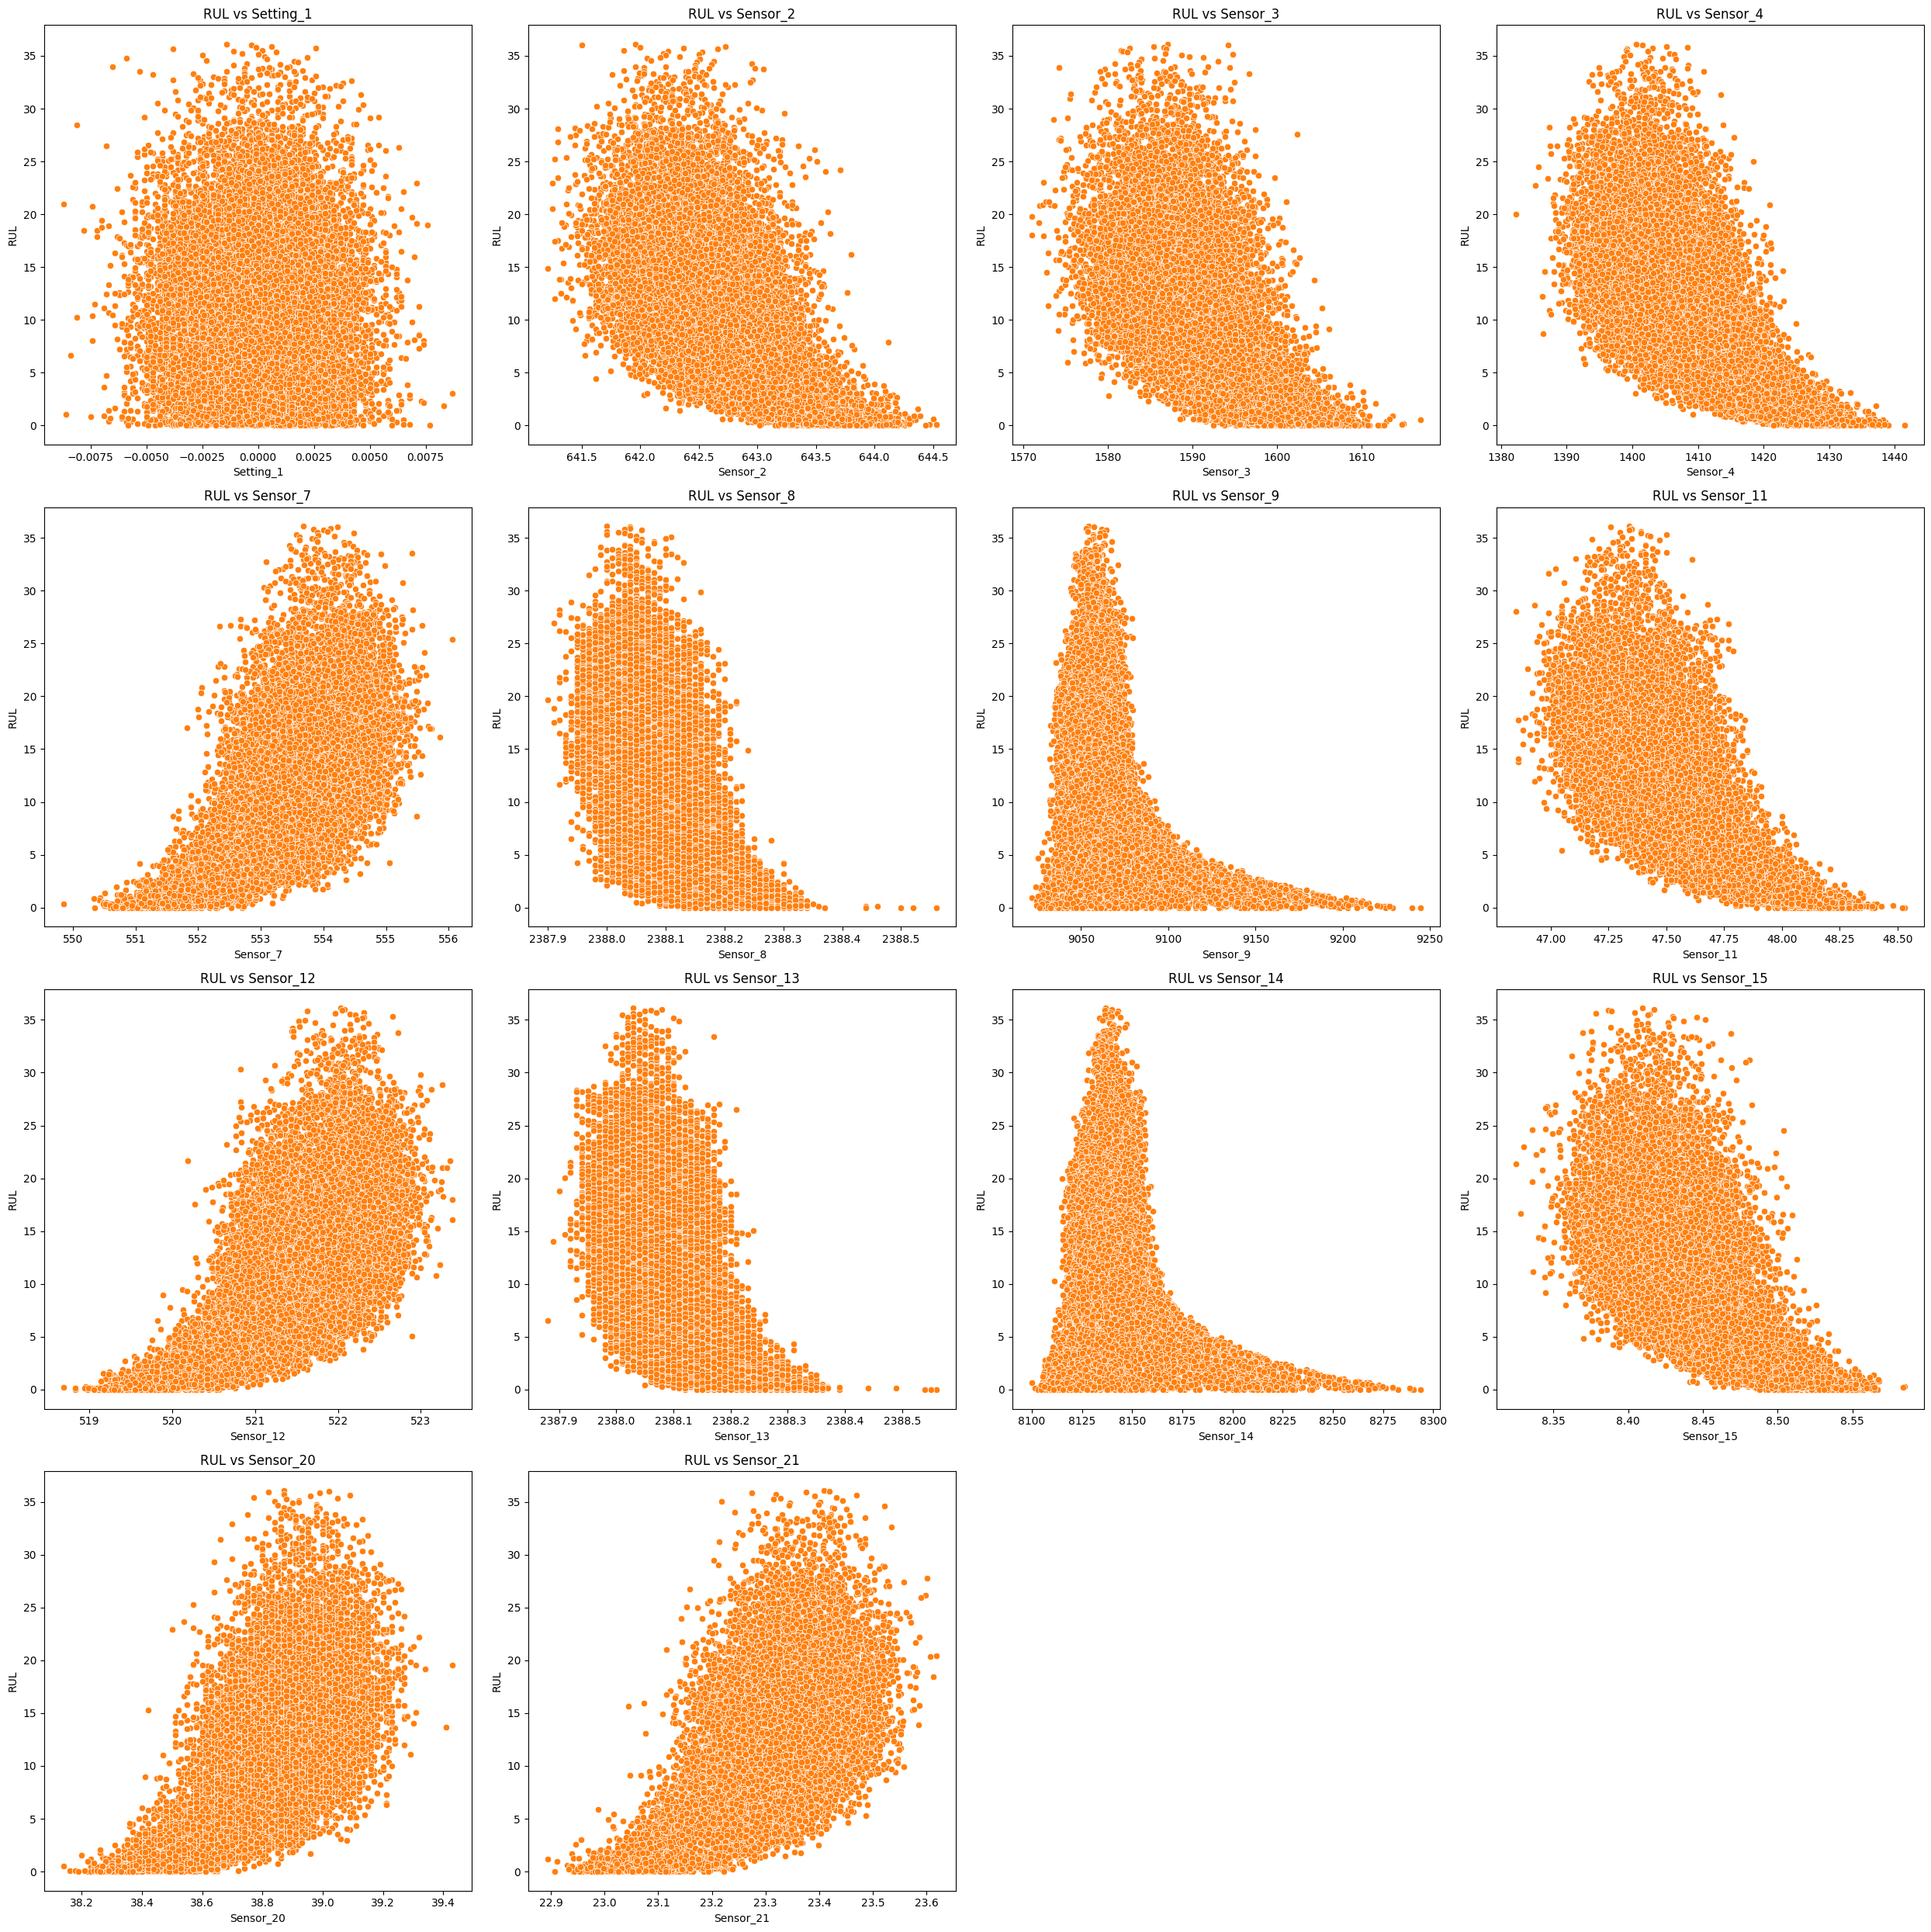

In [ ]:
features =data[['Setting_1','Sensor_2', 'Sensor_3', 'Sensor_4','Sensor_7','Sensor_8', 'Sensor_9','Sensor_11', 'Sensor_12',
                'Sensor_13', 'Sensor_14', 'Sensor_15','Sensor_20', 'Sensor_21']]

plt.figure(figsize=(25, 25))
plotno = 1

for i in features:
  if plotno < 16:
    plt.subplot(4,4, plotno)
    sns.scatterplot(x=data[i], y= data["RUL"], color='#ff7f0e')
    plt.xlabel(i)
    plt.ylabel("RUL")
    plt.title(f"RUL vs {i}")
  plotno+=1


plt.tight_layout()
plt.show()

**RUL Decreases Over Cycle**

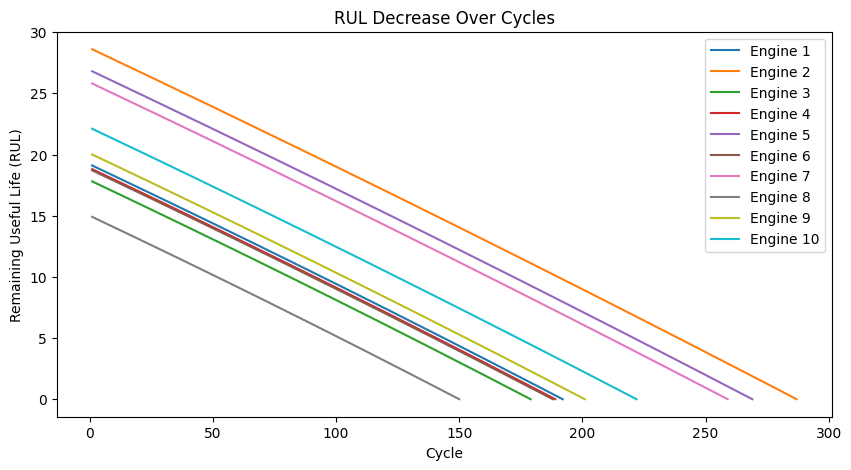

In [ ]:
plt.figure(figsize=(10,5))
for engine_id in data["Engine_ID"].unique()[:10]:  # First 5 engines
    engine_data = data[data["Engine_ID"] == engine_id]
    plt.plot(engine_data["Cycle"], engine_data["RUL"], label=f"Engine {engine_id}")

plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.title("RUL Decrease Over Cycles")
plt.legend()
plt.show()


**RUL Distribution Across Cycle Ranges**

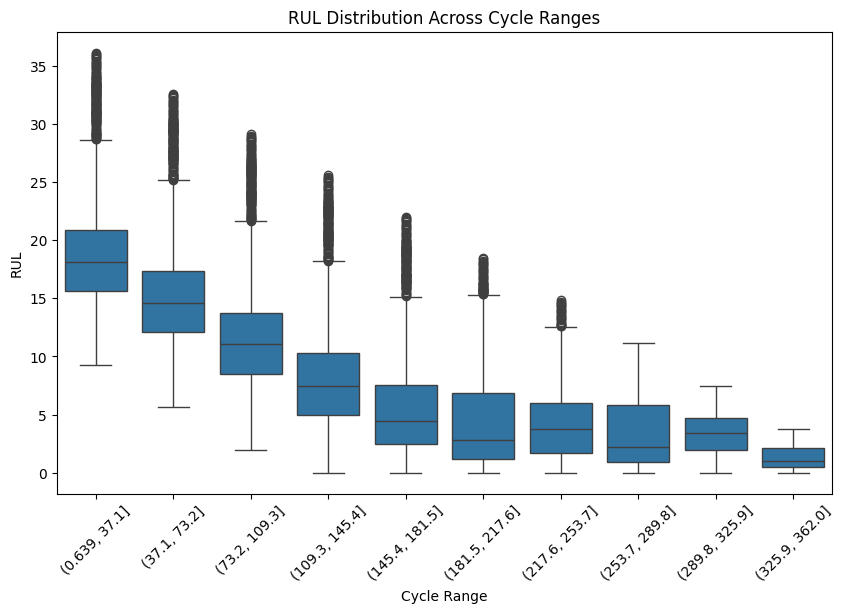

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=pd.cut(data["Cycle"], bins=10), y=data["RUL"])
plt.xticks(rotation=45)
plt.xlabel("Cycle Range")
plt.ylabel("RUL")
plt.title("RUL Distribution Across Cycle Ranges")
plt.show()

**Distribution of Mean of Data**

<ipython-input-16-139a6d838fae>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[features].mean(axis=1),color='ORANGE', kde=True,bins=120)


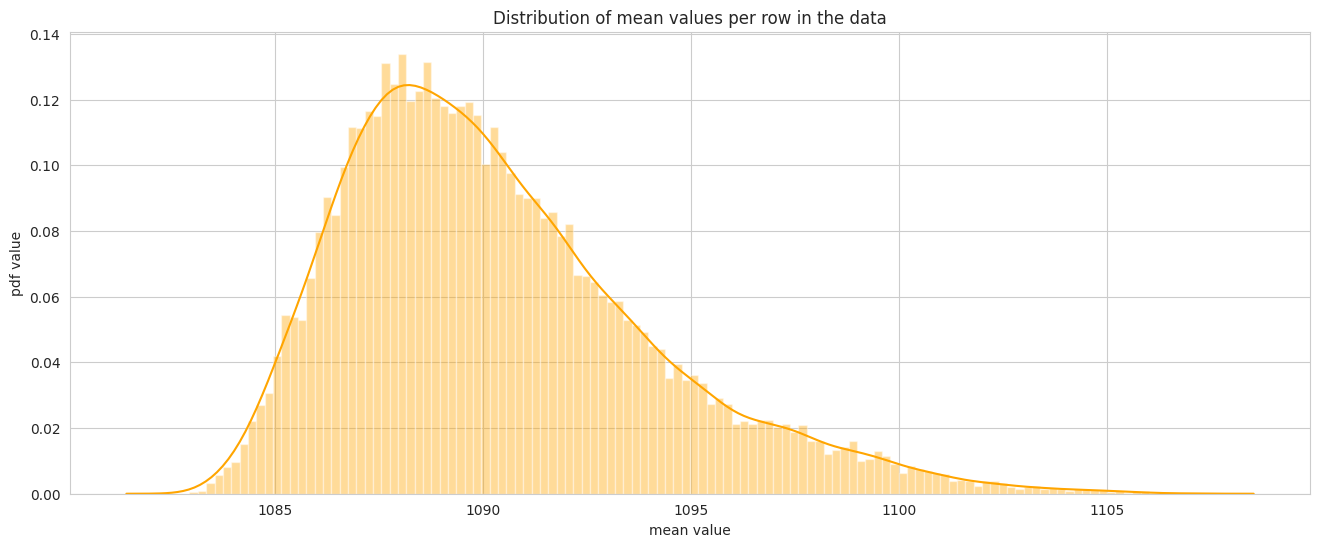

In [ ]:
plt.figure(figsize=(16,6))
sns.set_style('whitegrid')
features = data.columns.values
plt.title('Distribution of mean values per row in the data')
plt.xlabel('mean value')
plt.ylabel('pdf value')
sns.distplot(data[features].mean(axis=1),color='ORANGE', kde=True,bins=120)
plt.show()

**Distribution of Standarad Deviation of Data**

<ipython-input-17-1217e17f2757>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[features].std(axis=1),color='ORANGE', kde=True,bins=120)


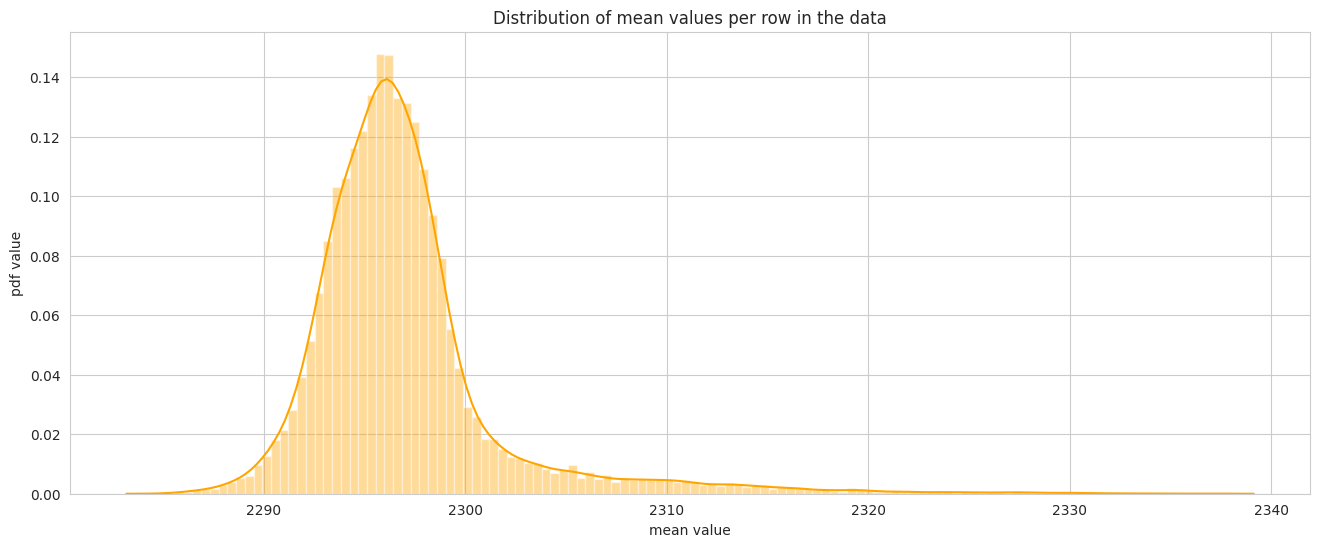

In [ ]:
plt.figure(figsize=(16,6))
sns.set_style('whitegrid')
features = data.columns.values[1:29]
plt.title('Distribution of mean values per row in the data')
plt.xlabel('mean value')
plt.ylabel('pdf value')
sns.distplot(data[features].std(axis=1),color='ORANGE', kde=True,bins=120)
plt.show()

In [ ]:
total_engine = np.unique(data["Engine_ID"])
print(f"Total Engines:{total_engine}")

Total Engines:[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


**After how many cycle engine fails**

In [ ]:
num_of_cycle_to_failure = data.groupby("Engine_ID")["Cycle"].count()
print(f"Engine fails after the number of cycle:{num_of_cycle_to_failure.values}")

Engine fails after the number of cycle:[192 287 179 189 269 188 259 150 201 222 240 170 163 180 207 209 276 195
 158 234 195 202 168 147 230 199 156 165 163 194 234 191 200 195 181 158
 170 194 128 188 216 196 207 192 158 256 214 231 215 198 213 213 195 257
 193 275 137 147 231 172 185 180 174 283 153 202 313 199 362 137 208 213
 213 166 229 210 154 231 199 185 240 214 293 267 188 278 178 213 217 154
 135 341 155 258 283 336 202 156 185 200]


* First engine fail after the 192 cycle, second engine fails after the 287 cycle and similar for other engines.

In [ ]:
data.head()

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Health_index,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.099503,19.104666
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.099007,19.009285
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.098510,18.913856
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.098012,18.818381
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.097515,18.722857


In [ ]:
feature = data[["Setting_3","Sensor_1","Sensor_5","Sensor_6","Sensor_10","Sensor_16","Sensor_18","Sensor_19"]]
for var in feature:
  print(f"{var}: {feature[var].unique()}")

Setting_3: [100.]
Sensor_1: [518.67]
Sensor_5: [14.62]
Sensor_6: [21.61 21.6 ]
Sensor_10: [1.3]
Sensor_16: [0.03]
Sensor_18: [2388]
Sensor_19: [100.]


* Drop all constant features present in the dataset.

## **DATA PREPROCESSING**

#### **1.Check Missing Value**

In [ ]:
## Check Missing Value
data.isnull().sum()

,0
Engine_ID,0
Cycle,0
Setting_1,0
Setting_2,0
Setting_3,0
Sensor_1,0
Sensor_2,0
Sensor_3,0
Sensor_4,0
Sensor_5,0


In [ ]:
## Categorical data is not present so we directly move to the next step i.e outlier handling

#### **2.Outlier Handling**

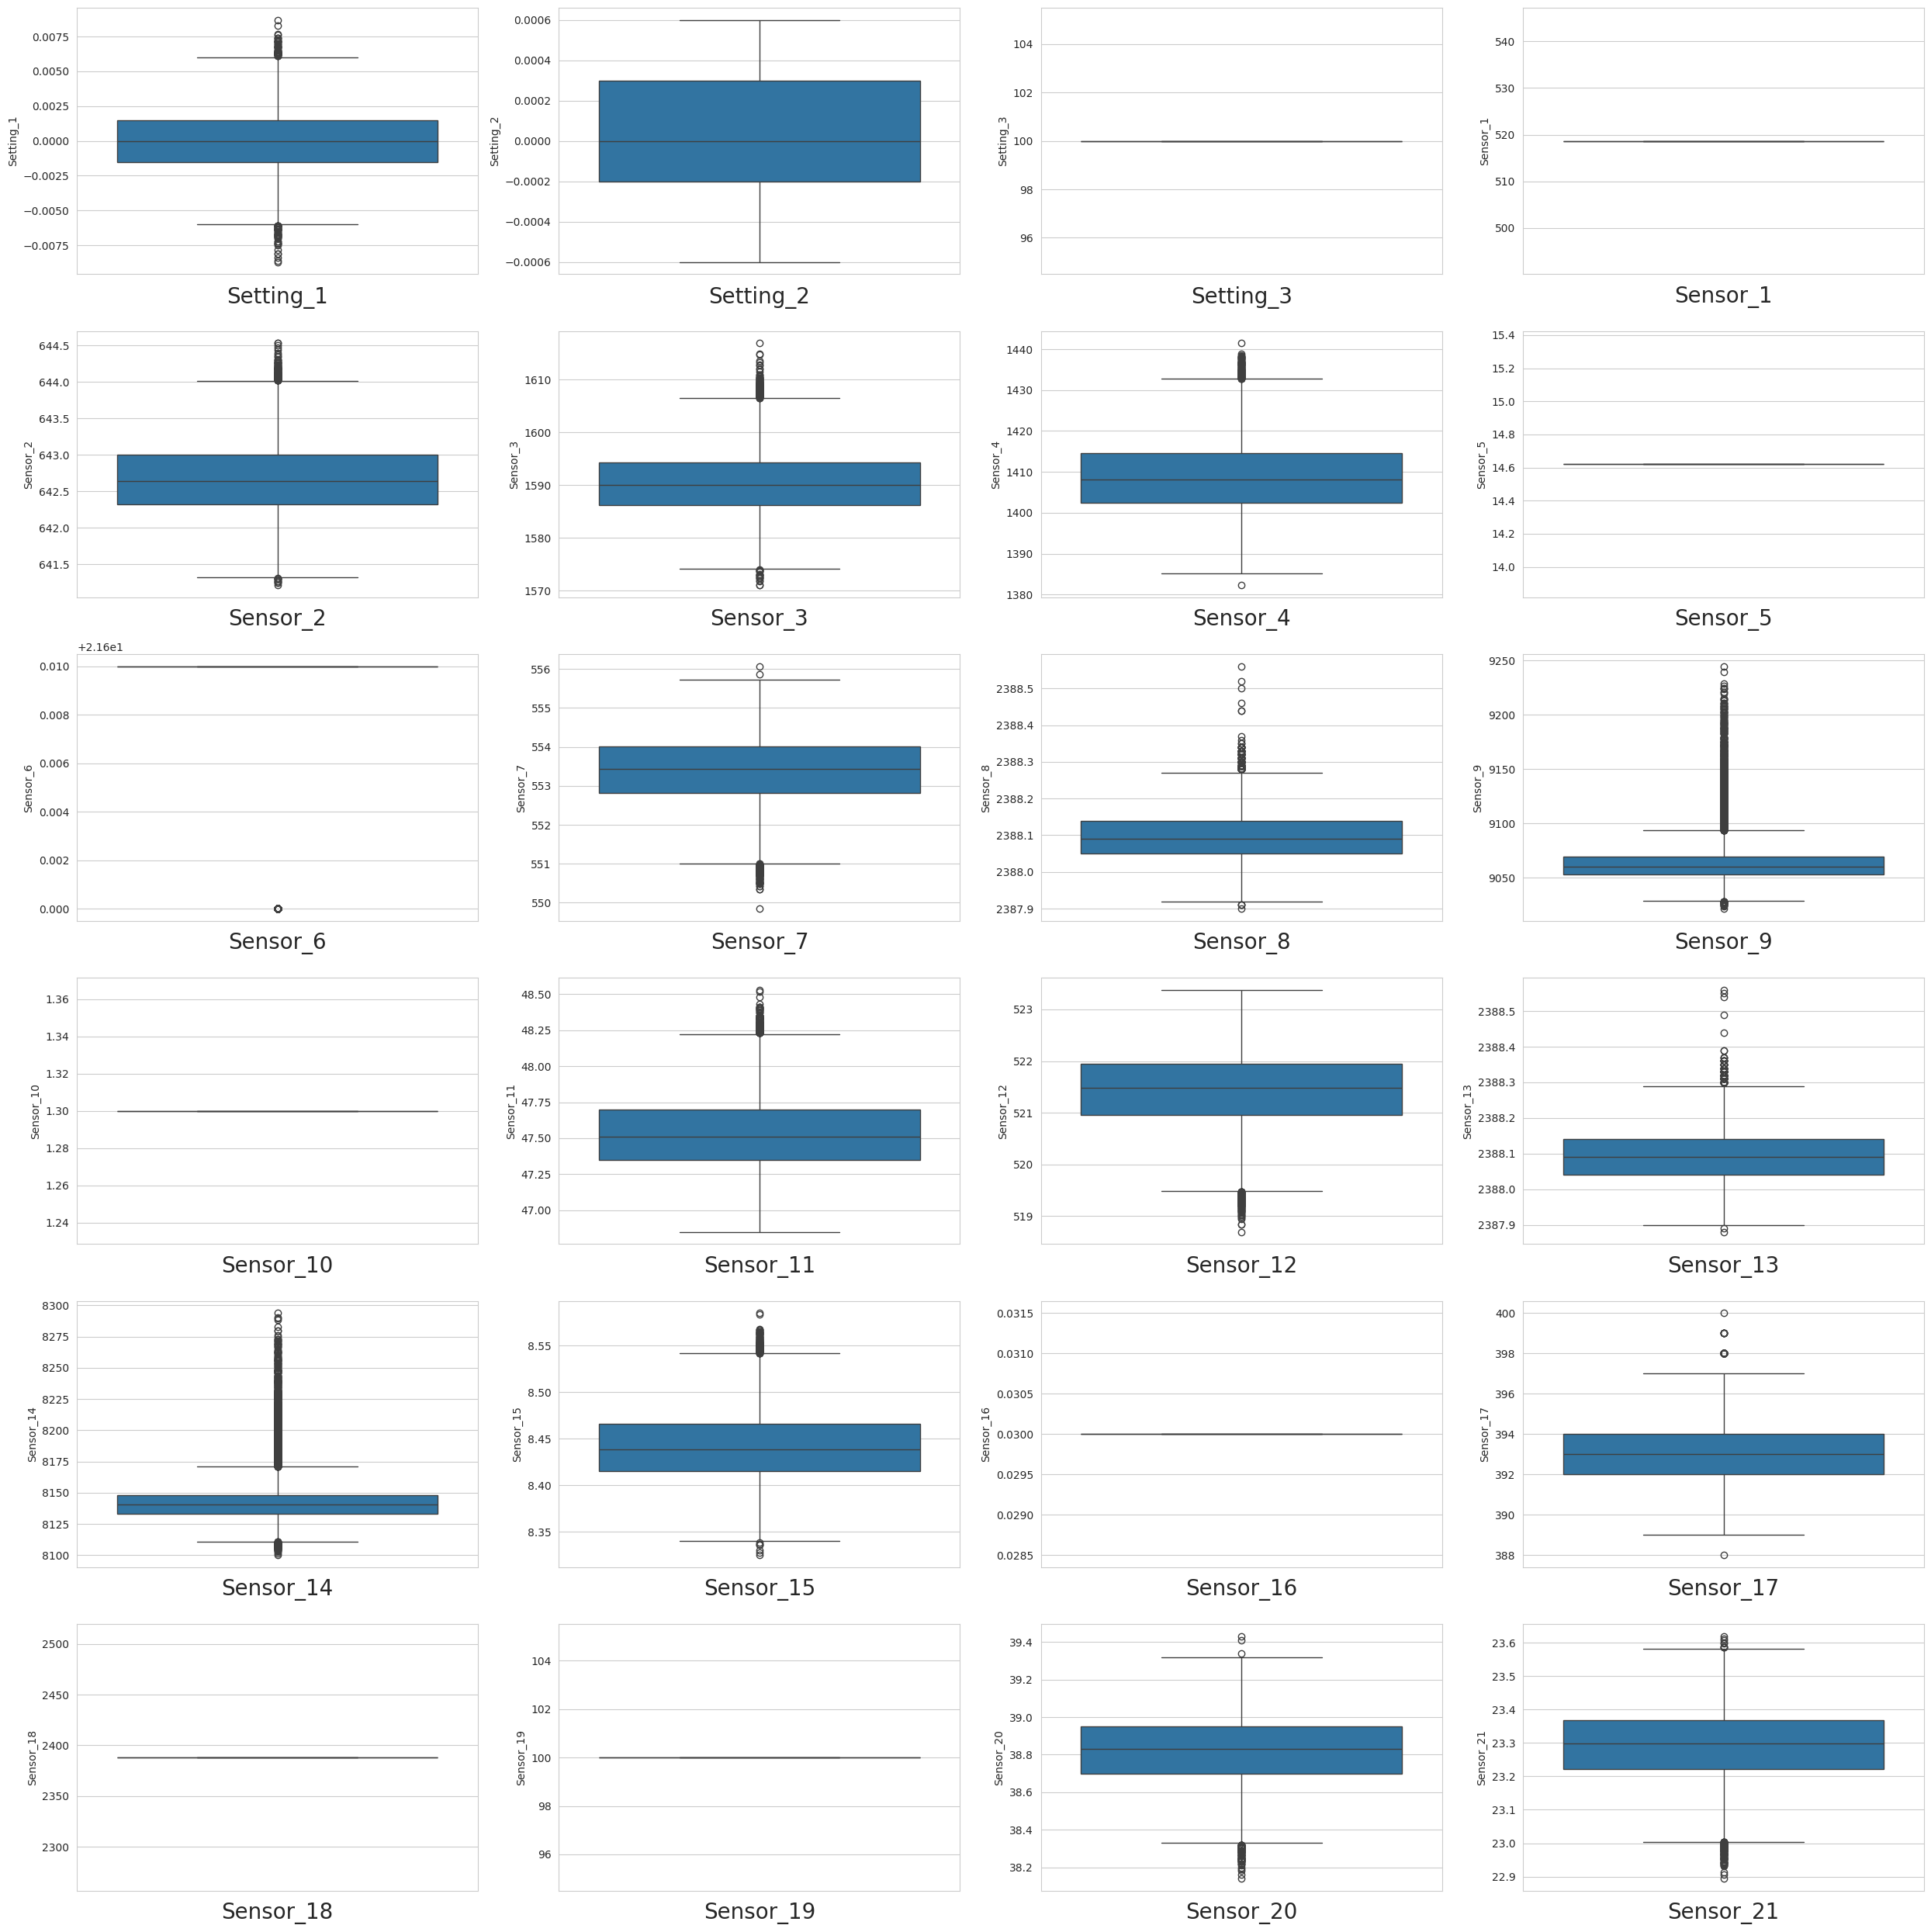

In [ ]:
out = data.iloc[:,2:-2]

plt.figure(figsize=(25,25)) # defining canvas size
plotno = 1 # counter

for column in out: # iteration of columns / acessing the columns from count
    if plotno<=24:    # set the limit
        plt.subplot(6,4,plotno) # # plotting 24 graphs (6-rows,4-columns) ,plotnumber is for count
        sns.boxplot(out[column]) # Plotting box plots to detect the outlier
        plt.xlabel(column,fontsize=20)  # assigning name to x-axis and font size is 20
    plotno+=1 # counter increment
plt.tight_layout()
plt.show() # used to hide the storage loction

* Empherical Rule (Features close to normal distribution) -> setting_1, Sensor_2, Sensor_3, Sensor_4, Sensor_7, Sensor_20 (Use Mean to impute the outlier)

* IQR (Features are not normally distributed) -> Sensor_8, Sensor_9, Sensor_11, Sensor_12, Sensor_13, Sensor_14, Sensor_15, Sensor_17, Sensor_21 (Use Median to impute the outliers)


**Note:If feature contain more than 5% outliers these outliers are not handled**

#### **Empherical Rule**

**1.Setting_1**



In [ ]:
upper_limit = data.Setting_1.mean() + 3*data.Setting_1.std()
print("Upper limit:",upper_limit)
lower_limit = data.Setting_1.mean() - 3*data.Setting_1.std()
print("Lower limit:",lower_limit)

Upper limit: 0.006553070200178947
Lower limit: -0.00657081049391168


In [ ]:
# Getting the percentage of outlier
len(data.loc[data['Setting_1'] > upper_limit])/data.shape[0]*100

0.12117686975910039

**2.Sensor_2**

In [ ]:
upper_limit = data.Sensor_2.mean() + 3*data.Sensor_2.std()
print("Upper limit:",upper_limit)
lower_limit = data.Sensor_2.mean() - 3*data.Sensor_2.std()
print("Lower limit:",lower_limit)

Upper limit: 644.1810933567864
Lower limit: 641.1807737364228


In [ ]:
print(len(data.loc[data['Sensor_2'] < lower_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_2'] > upper_limit])/data.shape[0]*100)

0.0
0.15025931850128446


**3.Sensor_3**

In [ ]:
upper_limit = data.Sensor_3.mean() + 3*data.Sensor_3.std()
print("Upper limit:",upper_limit)
lower_limit = data.Sensor_3.mean() - 3*data.Sensor_3.std()
print("Lower limit:",lower_limit)

Upper limit: 1608.9165671669928
Lower limit: 1572.129670048848


In [ ]:
print(len(data.loc[data['Sensor_3'] < lower_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_3'] > upper_limit])/data.shape[0]*100)

0.01938829916145606
0.20842421598565264


In [ ]:
data.loc[data['Sensor_3'] < lower_limit,'Sensor_3']=data['Sensor_3'].mean()

**4.Sensor_4**

In [ ]:
upper_limit = data.Sensor_4.mean() + 3*data.Sensor_4.std()
print("Upper limit:",upper_limit)
lower_limit = data.Sensor_4.mean() - 3*data.Sensor_4.std()
print("Lower limit:",lower_limit)

Upper limit: 1435.9355960293826
Lower limit: 1381.9319673461202


In [ ]:
print(len(data.loc[data['Sensor_4'] < lower_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_4'] > upper_limit])/data.shape[0]*100)

0.0
0.17449469245310456


**5.Sensor_7**

In [ ]:
upper_limit = data.Sensor_7.mean() + 3*data.Sensor_7.std()
print("Upper limit:",upper_limit)
lower_limit = data.Sensor_7.mean() - 3*data.Sensor_7.std()
print("Lower limit:",lower_limit)

Upper limit: 556.0229879842742
Lower limit: 550.7124344382938


In [ ]:
print(len(data.loc[data['Sensor_7'] < lower_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_7'] > upper_limit])/data.shape[0]*100)

0.1599534680820125
0.004847074790364015


In [ ]:
data.loc[data['Sensor_7'] < lower_limit,'Sensor_7']=data['Sensor_7'].mean()

**6.Sensor_20**

In [ ]:
upper_limit = data.Sensor_20.mean() + 3*data.Sensor_20.std()
print("Upper limit:",upper_limit)
lower_limit = data.Sensor_20.mean() - 3*data.Sensor_20.std()
print("Lower limit:",lower_limit)

Upper limit: 39.35850994427727
Lower limit: 38.2740313770353


In [ ]:
print(len(data.loc[data['Sensor_20'] < lower_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_20'] > upper_limit])/data.shape[0]*100)

0.1987300664049246
0.00969414958072803


In [ ]:
data.loc[data['Sensor_20'] > upper_limit,'Sensor_20']=data['Sensor_20'].mean()

#### **IQR**

**1.Sensor_8**

In [ ]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['Sensor_8'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['Sensor_8'].quantile(0.25)
Q3 = data['Sensor_8'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 0.08999999999969077
Minimum limit: 2387.915000000001
Maximum Limit: 2388.2749999999996


In [ ]:
print(len(data.loc[data['Sensor_8'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_8'] > max_limit])/data.shape[0]*100)

0.01938829916145606
1.5316756337550288


In [ ]:
# Impute outlier
data.loc[data['Sensor_8'] < min_limit,'Sensor_8']=data['Sensor_8'].median()
data.loc[data['Sensor_8'] > max_limit,'Sensor_8']=data['Sensor_8'].median()

**2.Sensor_9**

In [ ]:
iqr = stats.iqr(data['Sensor_9'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['Sensor_9'].quantile(0.25)
Q3 = data['Sensor_9'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_9'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_9'] > max_limit])/data.shape[0]*100)

IQR: 16.31999999999971
Minimum limit: 9028.62
Maximum Limit: 9093.9
0.11148272017837235
8.060685376375359


In [ ]:
data.loc[data['Sensor_9'] < min_limit,'Sensor_9']=data['Sensor_9'].median()

**3.Sensor_11**

In [ ]:
iqr = stats.iqr(data['Sensor_11'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_11'].quantile(0.25)
Q3 = data['Sensor_11'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_11'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_11'] > max_limit])/data.shape[0]*100)

IQR: 0.3500000000000014
Minimum limit: 46.825
Maximum Limit: 48.22500000000001
0.0
0.8094614899907905


**4.Sensor_12**

In [ ]:
iqr = stats.iqr(data['Sensor_12'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_12'].quantile(0.25)
Q3 = data['Sensor_12'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_12'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_12'] > max_limit])/data.shape[0]*100)

IQR: 0.9900000000000091
Minimum limit: 519.475
Maximum Limit: 523.4350000000001
0.7076729193931462
0.0


**5.Sensor_13**

In [ ]:
iqr = stats.iqr(data['Sensor_13'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_13'].quantile(0.25)
Q3 = data['Sensor_13'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_13'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_13'] > max_limit])/data.shape[0]*100)

IQR: 0.09999999999990905
Minimum limit: 2387.8900000000003
Maximum Limit: 2388.29
0.00969414958072803
0.7706848916678785


In [ ]:
data.loc[data['Sensor_13'] < min_limit,'Sensor_13']=data['Sensor_13'].median()

**6.Sensor_14**

In [ ]:
iqr = stats.iqr(data['Sensor_14'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_14'].quantile(0.25)
Q3 = data['Sensor_14'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_14'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_14'] > max_limit])/data.shape[0]*100)

IQR: 15.06500000000051
Minimum limit: 8110.647499999999
Maximum Limit: 8170.907500000001
0.2908244874218409
7.188211914109835


**7.Sensor_15**

In [ ]:
iqr = stats.iqr(data['Sensor_15'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_15'].quantile(0.25)
Q3 = data['Sensor_15'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_15'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_15'] > max_limit])/data.shape[0]*100)

IQR: 0.050700000000000855
Minimum limit: 8.338849999999997
Maximum Limit: 8.54165
0.033929523532548106
0.5477194513111338


In [ ]:
data.loc[data['Sensor_15'] < min_limit,'Sensor_15']=data['Sensor_15'].median()

**8.Sensor_17**

In [ ]:
iqr = stats.iqr(data['Sensor_17'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_17'].quantile(0.25)
Q3 = data['Sensor_17'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_17'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_17'] > max_limit])/data.shape[0]*100)

IQR: 2.0
Minimum limit: 389.0
Maximum Limit: 397.0
0.004847074790364015
0.38776598322912126


In [ ]:
data.loc[data['Sensor_17'] < min_limit,'Sensor_17']=data['Sensor_17'].median()

**9.Sensor_21**

In [ ]:
iqr = stats.iqr(data['Sensor_21'],interpolation='midpoint')
print("IQR:",iqr)

Q1 = data['Sensor_21'].quantile(0.25)
Q3 = data['Sensor_21'].quantile(0.75)

min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

print(len(data.loc[data['Sensor_21'] < min_limit])/data.shape[0]*100)
print(len(data.loc[data['Sensor_21'] > max_limit])/data.shape[0]*100)

IQR: 0.14499999999999957
Minimum limit: 23.0043
Maximum Limit: 23.5843
0.6155784983762299
0.04362367311327614


In [ ]:
data.loc[data['Sensor_21'] > max_limit,'Sensor_21']=data['Sensor_21'].median()

## **FEATURE SELECTION**

**1.Drop Unique and Constant Features**
* Unique Feature: Engine_ID
* Constan Feature (Std is zero): Sensor_1, Sensor_3, Sensor_5, Sensor_10, Sensor_16, Sensor_18, Sensor_19

In [ ]:
data.drop(["Setting_3","Sensor_1","Sensor_5","Sensor_6","Sensor_10","Sensor_16","Sensor_18","Sensor_19","Engine_ID"], axis=1, inplace=True)

In [ ]:
data.head()

,Cycle,Setting_1,Setting_2,Sensor_2,Sensor_3,Sensor_4,Sensor_7,Sensor_8,Sensor_9,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_17,Sensor_20,Sensor_21,Health_index,RUL
0,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.099503,19.104666
1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.099007,19.009285
2,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.098510,18.913856
3,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.098012,18.818381
4,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.097515,18.722857


**2.Check Correlation**

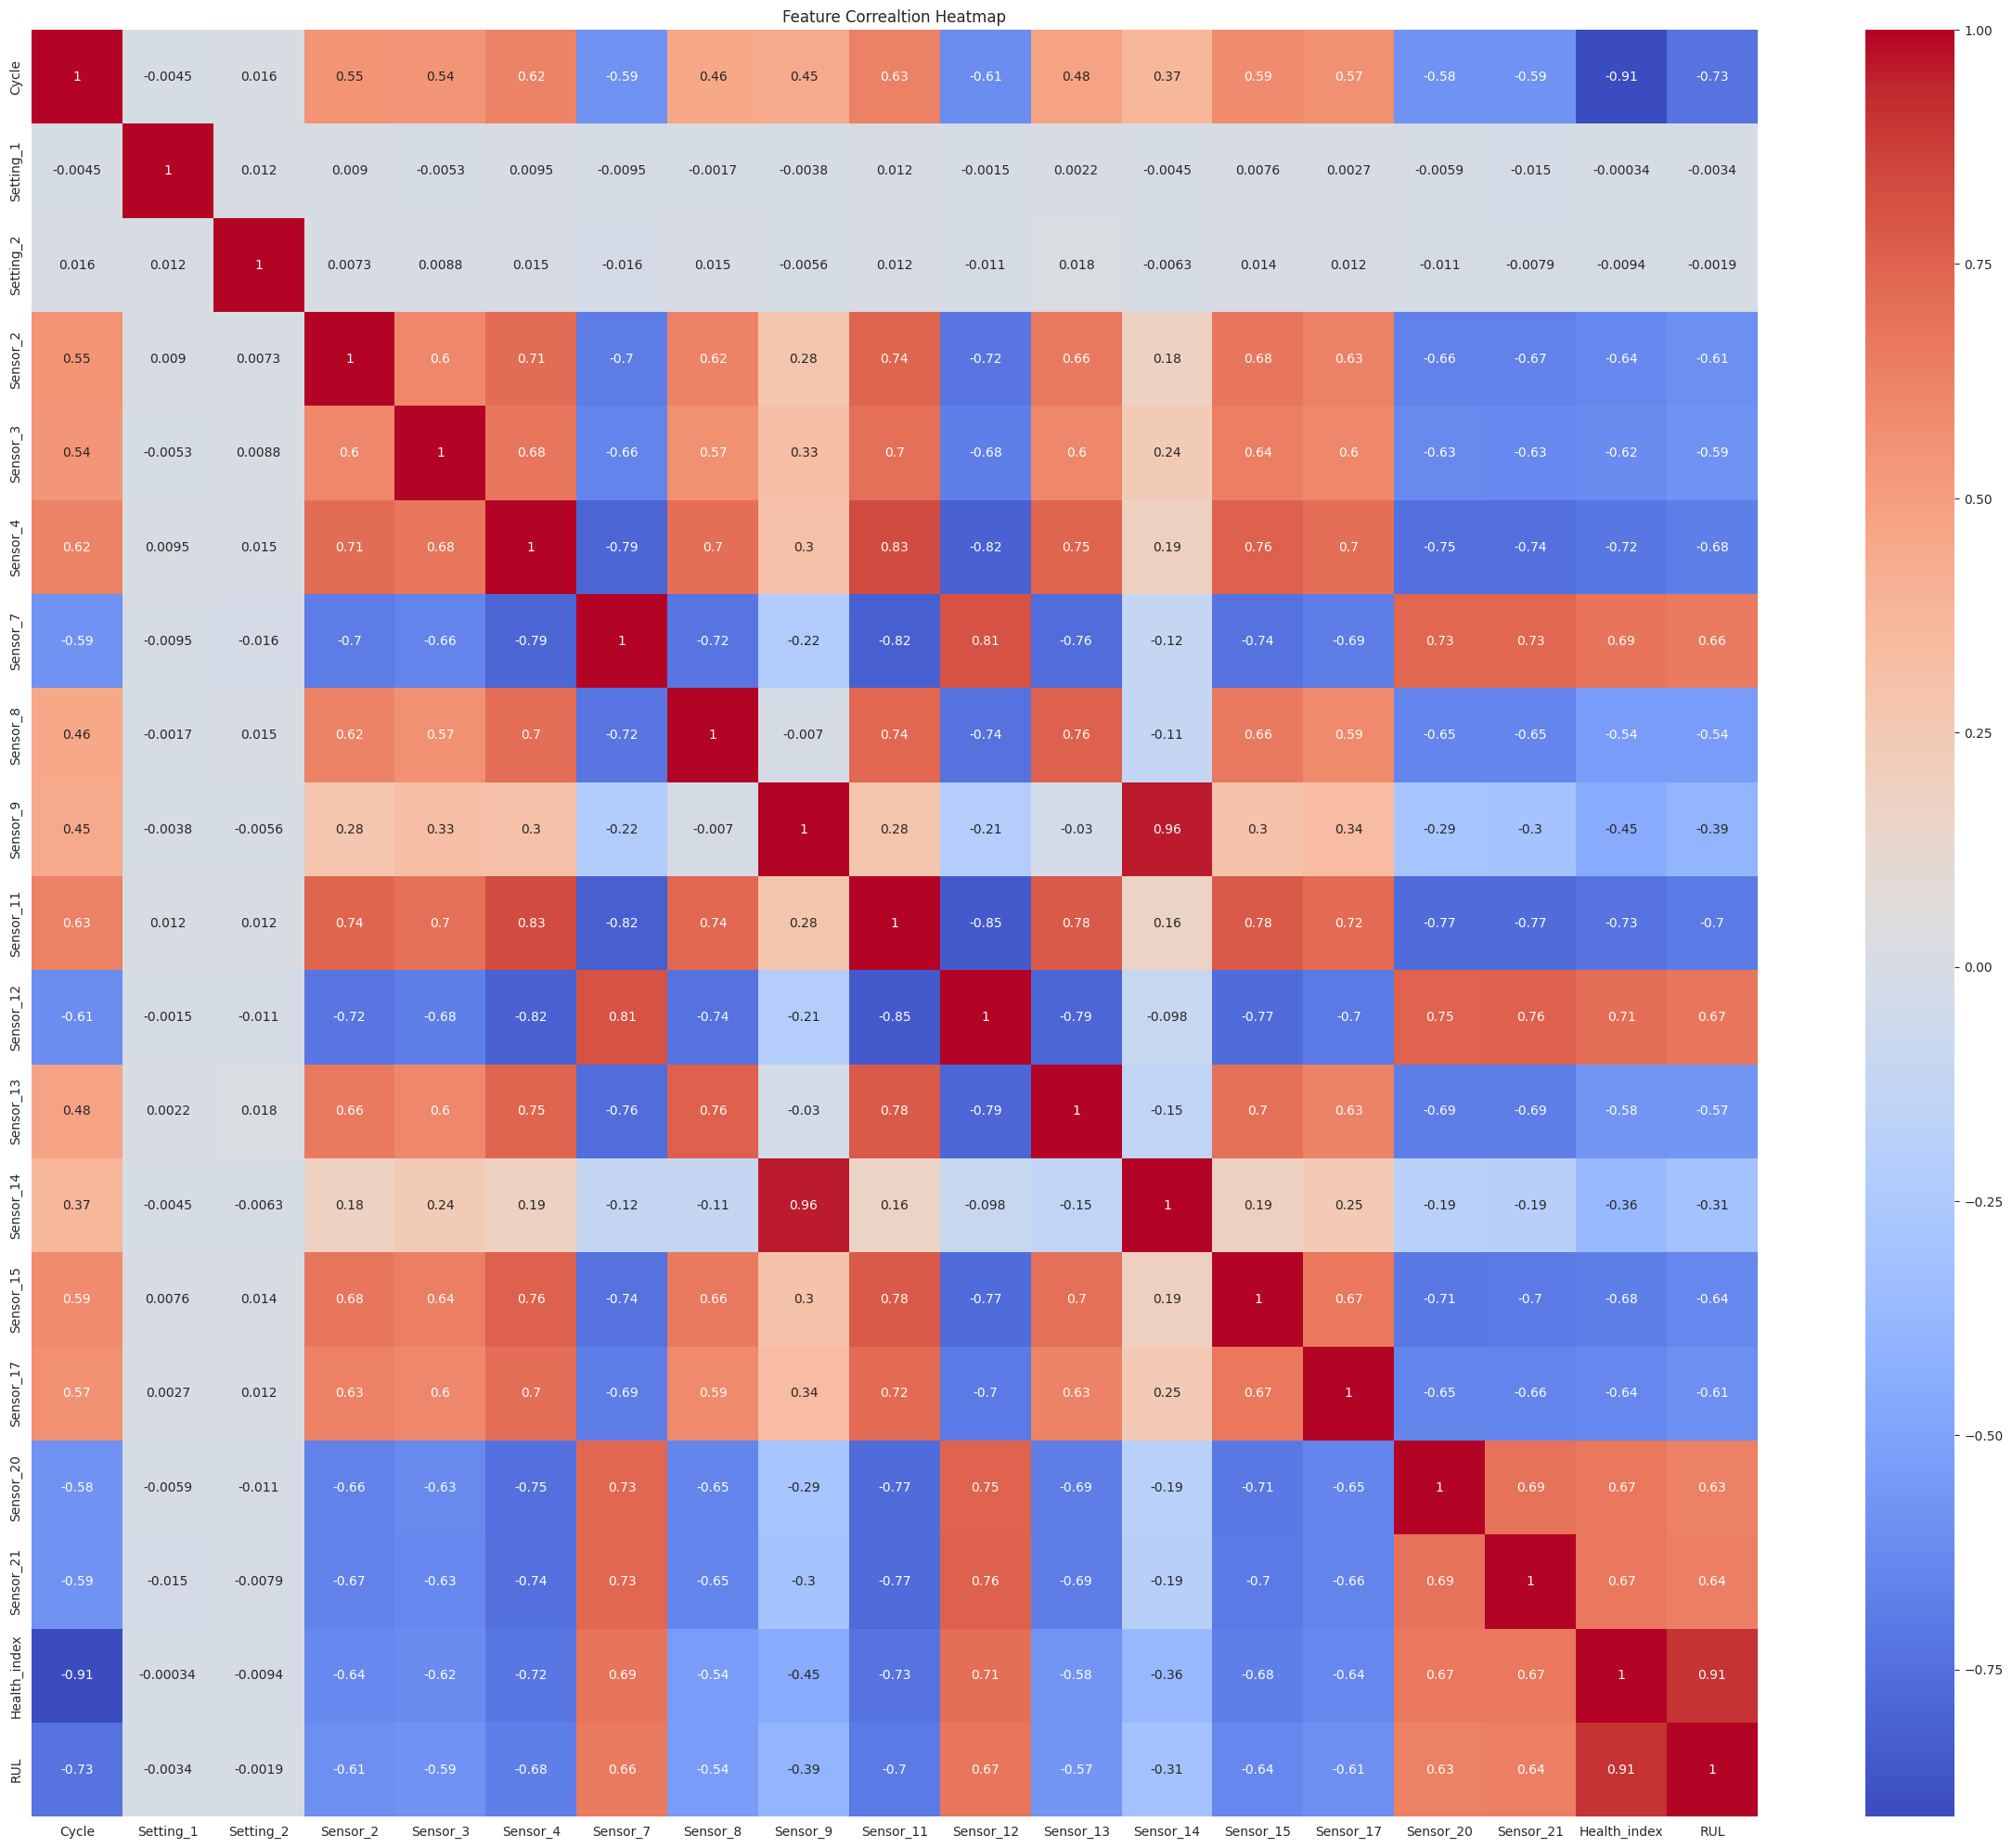

In [ ]:
plt.figure(figsize=(30,25))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("Feature Correaltion Heatmap")
plt.show()

In [ ]:
# Drop highly correlated feature
data.drop(["Sensor_14","Health_index"], axis=1, inplace=True)

**3.Check Duplicates**

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(20631, 17)

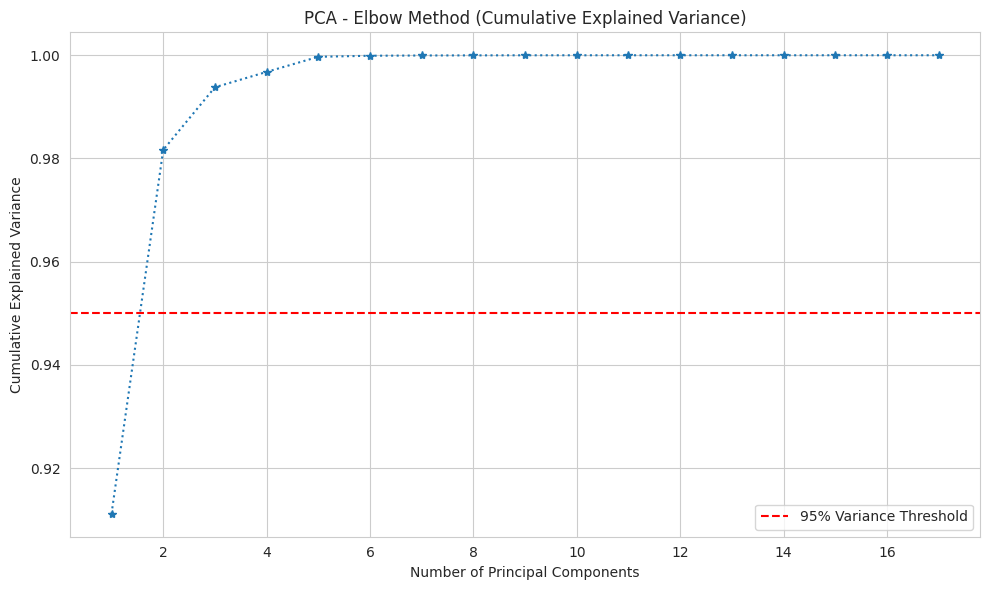

In [ ]:
pca = PCA()
pca.fit(data)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Elbow plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='*', linestyle=':')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Elbow Method (Cumulative Explained Variance)')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

* select 4 components beacuse it explain the 99.99% varaiance of the dataset.

In [ ]:
# Save preprocess and pca data
data.to_csv("preprocess_data.csv", index=False)

## **Model Building**
* Loading pre-process data
* Define dependant & independant features
* Split training and testing data
* Model creation, prediction & evaluation
* Model saving

In [2]:
data = pd.read_csv('preprocess_data.csv')

In [3]:
## Define dependant and independand feature
X = data.iloc[:,:-1]
y = data.RUL

In [4]:
X.head()

,Cycle,Setting_1,Setting_2,Sensor_2,Sensor_3,Sensor_4,Sensor_7,Sensor_8,Sensor_9,Sensor_11,Sensor_12,Sensor_13,Sensor_15,Sensor_17,Sensor_20,Sensor_21
0,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190
1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236
2,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442
3,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739
4,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044


In [5]:
y.head()

,RUL
0,19.104666
1,19.009285
2,18.913856
3,18.818381
4,18.722857


In [6]:
## Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=45)

In [7]:
# use scaling and reduce the dimensions of the dataset into 5

## Scaling
sc = MinMaxScaler()
X_train_scale = sc.fit_transform(X_train)
X_test_scale = sc.transform(X_test)

# apply pca
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scale)
X_test_pca = pca.transform(X_test_scale)

# save scaler and pca
joblib.dump(sc, 'new_scaler.joblib')
joblib.dump(pca, "new_pca.joblib")

['new_pca.joblib']

In [8]:
X_train_pca

array([[ 6.73754419e-01,  3.21718317e-01, -1.86072641e-01,
        -5.10360645e-02, -2.25579904e-02],
       [ 2.43810053e-01,  3.28026617e-01, -4.84469936e-02,
         3.05275631e-02,  8.44427035e-02],
       [-3.39366165e-01,  3.34100490e-01, -9.15672824e-02,
         7.24078201e-02, -2.06525095e-01],
       ...,
       [ 4.48678246e-01, -1.77015765e-01, -1.07022248e-01,
        -2.13430687e-01, -2.37442684e-02],
       [-5.27449396e-01,  4.18164064e-01, -2.47580320e-02,
        -1.96564642e-01, -1.07131149e-01],
       [ 6.49500499e-02,  1.64129103e-01,  1.18949642e-01,
         1.72950983e-01, -3.97298696e-05]])

In [9]:
y_train.head()

,RUL
18359,2.083900
17025,12.917317
5631,16.109268
2344,3.230153
12175,13.268688


In [10]:
print(f"Shape of training data: {X_train_pca.shape}")
print(f"Shape of testing data: {X_test_pca.shape}")

Shape of training data: (16504, 5)
Shape of testing data: (4127, 5)


### **Machine Learning Models**
**1. Random Forest Regressor**

In [ ]:
# define parameter grid
param_dist = {'n_estimators': [100, 200, 300, 500, 800],
              'max_depth': [10, 20, 30, 40, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['sqrt', 'log2', None],
              'bootstrap': [True, False]}

# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# RandomizedSearchCV setup
random_search = RandomizedSearchCV(estimator=rf,
                                   param_distributions=param_dist,
                                   n_iter=20,
                                   cv=5,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1,
                                   scoring='neg_root_mean_squared_error')

In [ ]:
# fit training data
random_search.fit(X_train_pca, y_train)

# best model
best_rf_model = random_search.best_estimator_
print(best_rf_model)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=10, n_estimators=500, random_state=42)


In [ ]:
# Make prediction on training as well as testing data
rf_train_predict = best_rf_model.predict(X_train_pca)
rf_test_predict = best_rf_model.predict(X_test_pca)

# Evaluate the model performance
RF_R2_TRAIN = r2_score(y_train, rf_train_predict)
print(f"R2 Score of Random Forest Regressor in Training {RF_R2_TRAIN}")

RF_R2_TEST = r2_score(y_test, rf_test_predict)
print(f"R2 Score of Random Regressor in Testing {RF_R2_TEST}")

mae = MAE(y_test, rf_test_predict)
mse = MSE(y_test,rf_test_predict )
rmse = np.sqrt(MSE(y_test, rf_test_predict))
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

R2 Score of Random Forest Regressor in Training 0.7583891316417133
R2 Score of Random Regressor in Testing 0.7184465590594349
MAE: 2.6105377844786295
MSE: 13.301178118056944
RMSE: 3.64707802467358


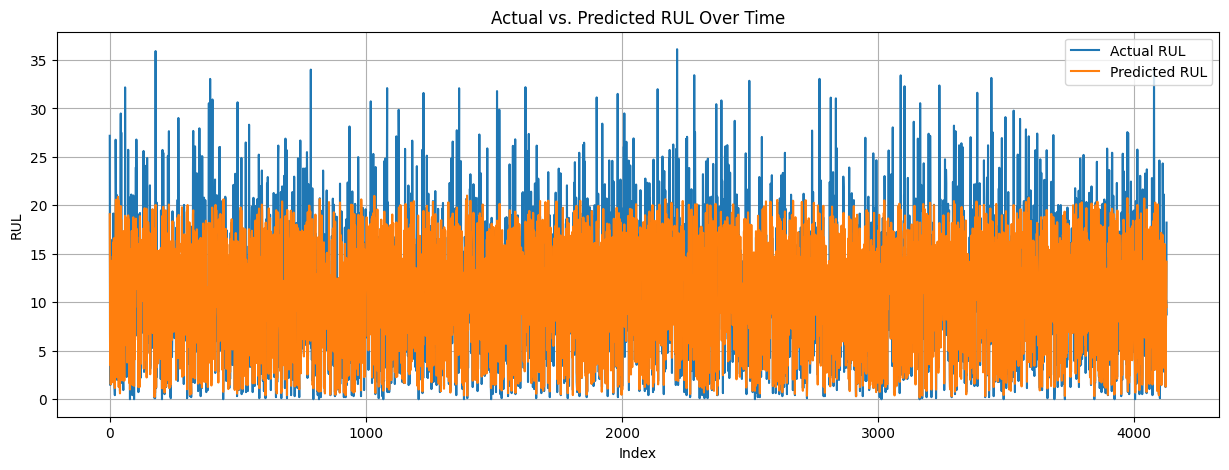

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.values, label="Actual RUL", linestyle="-")
plt.plot(rf_test_predict, label="Predicted RUL", linestyle="-")

plt.xlabel("Index")
plt.ylabel("RUL")
plt.title("Actual vs. Predicted RUL Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save model
joblib.dump(best_rf_model,"New_RandomForestRegressor.joblib")

['New_RandomForestRegressor.joblib']

**2. XGBoost**

In [ ]:
param_grid = {'n_estimators': [100, 200, 300, 500],
              'max_depth': [3, 5, 7, 10],
              'learning_rate': [0.0001, 0.001, 0.01, 0.1],
              'min_child_weight': [1, 3, 5],
              'gamma': [0, 0.1, 0.2, 0.5],
              'subsample': [0.6, 0.8, 1.0],
              'colsample_bytree': [0.6, 0.8, 1.0],
              'reg_alpha': [0, 0.01, 0.1],
              'reg_lambda': [1, 1.5, 2]}


In [ ]:
xgb = XGBRegressor(objective="reg:squarederror", seed=123)

random_search = RandomizedSearchCV(estimator=xgb,
                                    param_distributions=param_grid,
                                    n_iter=20,            # Try 20 combinations
                                    scoring='r2',         # Use R2 for evaluation
                                    cv=3,                 # 3-fold cross-validation
                                    verbose=2,
                                    random_state=42,
                                    n_jobs=-1)

random_search.fit(X_train_pca, y_train)

# Best model and performance
best_xgb = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [ ]:
## Make prediction
xgb_pred_train = best_xgb.predict(X_train_pca)
xgb_pred_test = best_xgb.predict(X_test_pca)

# R2 Score of Training and Testing
XGB_R2_TRAIN = r2_score(y_train, xgb_pred_train)
print(f"R2 Score of XGB Regressor in Training {XGB_R2_TRAIN}")

XGB_R2_TEST = r2_score(y_test, xgb_pred_test)
print(f"R2 Score of XGB Regressor in Testing {XGB_R2_TEST}")

# Testing RMSE
RMSE_TEST= np.sqrt(MSE(y_test, xgb_pred_test))
print(f"XGB Testing Error:: {RMSE_TEST}")

R2 Score of XGB Regressor in Training 0.7413794449818425
R2 Score of XGB Regressor in Testing 0.7212428405483899
XGB Testing Error:: 3.6289221382426033


In [ ]:
## Perfrom K-fold cross validation
cv_scores = cross_val_score(best_xgb, X_train_pca, y_train, cv=5, scoring='r2')

print(f"Mean R²: {np.mean(cv_scores)}, Std Dev: {np.std(cv_scores)}")

Mean R²: 0.7180485918130906, Std Dev: 0.007593648914210291


In [ ]:
mae = MAE(y_test, xgb_pred_test)
mse = MSE(y_test,xgb_pred_test )
rmse = np.sqrt(MSE(y_test, xgb_pred_test))
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 2.58821037645756
MSE: 13.169075885427267
RMSE: 3.6289221382426033


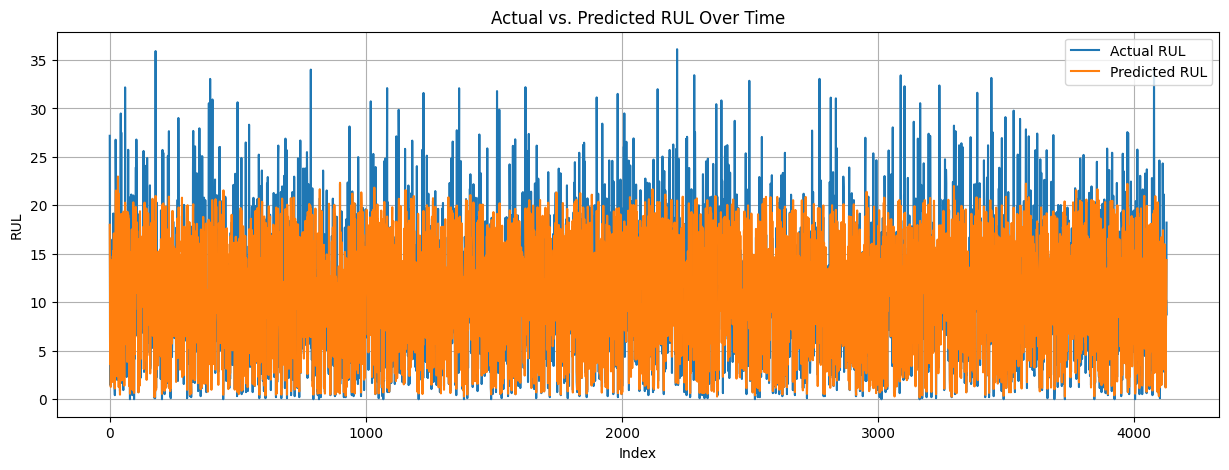

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.values, label="Actual RUL", linestyle="-")
plt.plot(xgb_pred_test, label="Predicted RUL", linestyle="-")

plt.xlabel("Index")
plt.ylabel("RUL")
plt.title("Actual vs. Predicted RUL Over Time")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
joblib.dump(best_xgb, "New_Xgb_model.joblib")

['New_Xgb_model.joblib']

**3. StackingRegressor**

In [ ]:
# Define base learners
base_learners = [('xgb', XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.01)),
                  ('rf', RandomForestRegressor(n_estimators=200, max_depth=10)),
                  ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)),
                  ('svr', SVR(kernel='rbf', C=10, gamma='scale'))]

# Define MLP as meta-model
meta_model = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)

# Create Stacking Regressor
stacking_model = StackingRegressor(estimators=base_learners,
                                  final_estimator=meta_model,
                                  passthrough=True,
                                  n_jobs=-1)

# Fit model
stacking_model.fit(X_train_pca, y_train)

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=10,
                                                     n_estimators=200)),
                              ('gbr', GradientBoostingRegressor()),
                              ('svr', SVR(C=10))],
                  final_estimator=MLPRegressor(hidden_layer_sizes=(50, 25),
                                               max_iter=500, random_state=42),
                  n_jobs=-1, passthrough=True)

In [ ]:
# Predict on training and testing data
train_pred = stacking_model.predict(X_train_pca)
test_pred = stacking_model.predict(X_test_pca)

# Evaluate
r2_train = r2_score(y_train, train_pred)
r2_test = r2_score(y_test, test_pred)

print(f"R2 Score Training: {r2_train}")
print(f"R2 Score Testing:  {r2_test:}")

R2 Score Training: 0.7528103384625506
R2 Score Testing:  0.7231261726972575


In [ ]:
mae = MAE(y_test, test_pred)
mse = MSE(y_test, test_pred)
rmse = np.sqrt(MSE(y_test, test_pred))
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 2.530836479531127
MSE: 13.080103304293582
RMSE: 3.616642545828048


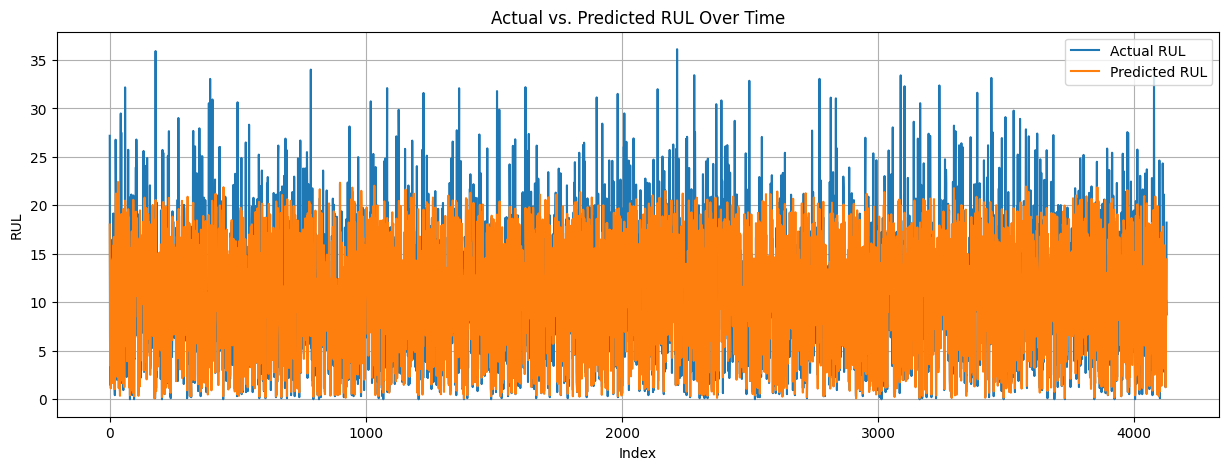

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.values, label="Actual RUL", linestyle="-")
plt.plot(test_pred, label="Predicted RUL", linestyle="-")

plt.xlabel("Index")
plt.ylabel("RUL")
plt.title("Actual vs. Predicted RUL Over Time")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
joblib.dump(stacking_model, 'New_Stacking_model.joblib')

['New_Stacking_model.joblib']

### **ML Model Performance Comparison**

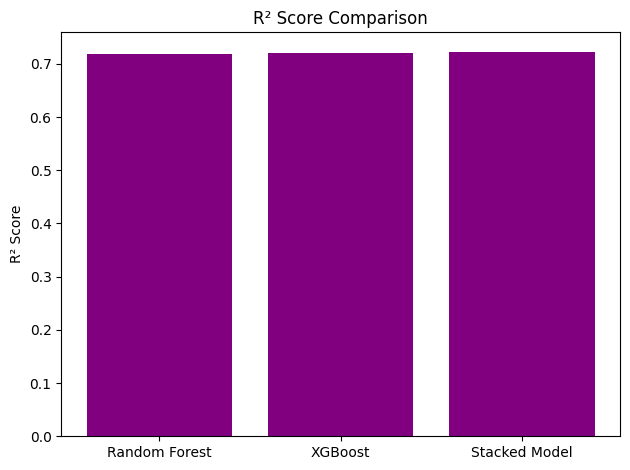

In [11]:
# R2 Scores
models = ['Random Forest', 'XGBoost', 'Stacked Model']
r2_scores = [0.7184, 0.7212, 0.7231]

plt.bar(models, r2_scores, color='purple')
plt.ylabel("R² Score")
plt.title("R² Score Comparison")
plt.tight_layout()
plt.show()

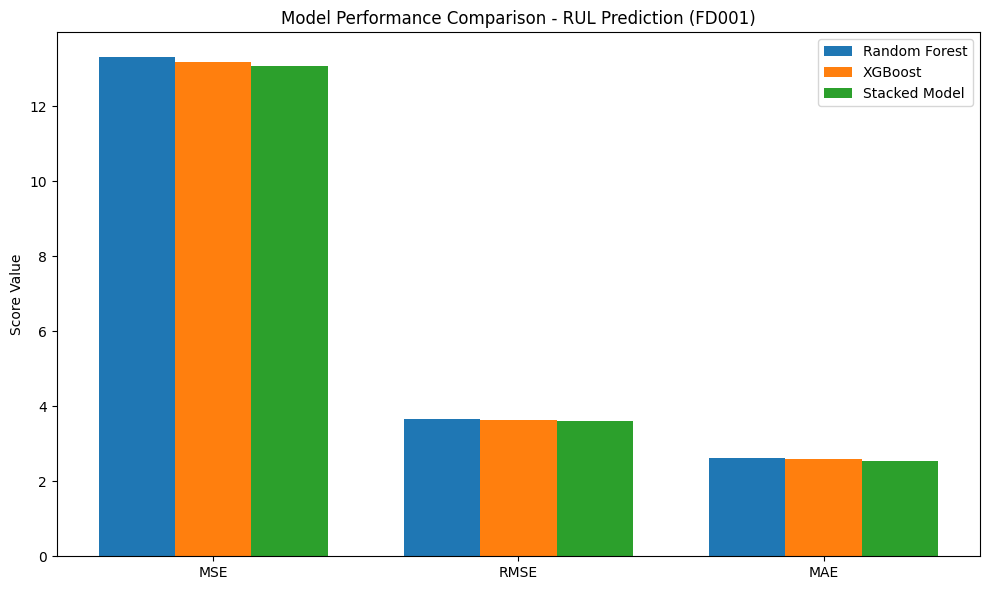

In [ ]:
# Model names and metrics
models = ['Random Forest', 'XGBoost', 'Stacked Model']
metrics = ["MSE", "RMSE", "MAE"]

# Scores for each model
rf_result = [13.301, 3.647, 2.6105]
xgb_result = [13.169, 3.6289, 2.5882]
stack_model = [13.080, 3.6166, 2.5308]

# Combine the results for plotting
scores = np.array([rf_result, xgb_result, stack_model])
x = np.arange(len(metrics))
width = 0.25

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(x - width, scores[0], width, label='Random Forest')
plt.bar(x, scores[1], width, label='XGBoost')
plt.bar(x + width, scores[2], width, label='Stacked Model')
plt.xticks(x, metrics)
plt.ylabel("Score Value")
plt.title("Model Performance Comparison - RUL Prediction (FD001)")
plt.legend()
plt.tight_layout()
plt.show()


### **Deep Learning Model**
**1. LSTM**

In [12]:
# Create sequences
def convert_into_3D(X, y, window_size):
  X_seq, y_seq = [], []
  for i in range(len(X) - window_size):
    X_seq.append(X[i:i + window_size])
    y_seq.append(y.iloc[i + window_size-1])
  return np.array(X_seq), np.array(y_seq)

# Define window size as 30
window_size = 30
X_train_seq, y_train_seq = convert_into_3D(X_train_pca, y_train, window_size)
X_test_seq, y_test_seq = convert_into_3D(X_test_pca, y_test, window_size)

In [13]:
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

X_train_seq shape: (16474, 30, 5)
y_train_seq shape: (16474,)


In [ ]:
time_steps = X_train_seq.shape[1]
num_of_features = X_train_seq.shape[2]
print(f"Time Steps:{time_steps}")
print(f"Num of Features:{num_of_features}")

Time Steps:30
Num of Features:5


In [ ]:
# create sequential model
lstm_model = Sequential()

lstm_model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, num_of_features)))
lstm_model.add(Dropout(0.5))
lstm_model.add(LSTM(64, activation='tanh', return_sequences=True))
lstm_model.add(Dropout(0.5))
lstm_model.add(LSTM(32, activation='tanh', return_sequences=False))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1))  # output layer

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# get model summary
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,465 (509.63 KB)

 Trainable params: 130,465 (509.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile model
lstm_model.compile(optimizer=('adam'),
                   loss='mse',
                   metrics=['mae'])

In [ ]:
# fit model for training
hist = lstm_model.fit(X_train_seq, y_train_seq,
                     validation_split=0.2,
                     epochs=100,
                     batch_size=64,
                     shuffle=False)

Epoch 1/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 30s 118ms/step - loss: 89.5630 - mae: 7.4588 - val_loss: 47.8014 - val_mae: 5.6870
Epoch 2/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - loss: 50.4683 - mae: 5.7948 - val_loss: 47.5718 - val_mae: 5.6918
Epoch 3/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - loss: 50.4708 - mae: 5.8374 - val_loss: 47.5775 - val_mae: 5.6914
Epoch 4/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - loss: 50.2855 - mae: 5.8226 - val_loss: 47.5867 - val_mae: 5.6908
Epoch 5/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - loss: 50.4796 - mae: 5.8119 - val_loss: 47.5735 - val_mae: 5.6916
Epoch 6/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - loss: 50.2085 - mae: 5.8116 - val_loss: 47.5821 - val_mae: 5.6911
Epoch 7/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - loss: 50.2154 - mae: 5.8206 - val_loss: 47.5759 - val_mae: 5.6914
Epoch 8/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - loss: 50.1132 - mae: 5.8125 - val_loss: 47.5747 - val_mae: 5.6907
Epoch 9/

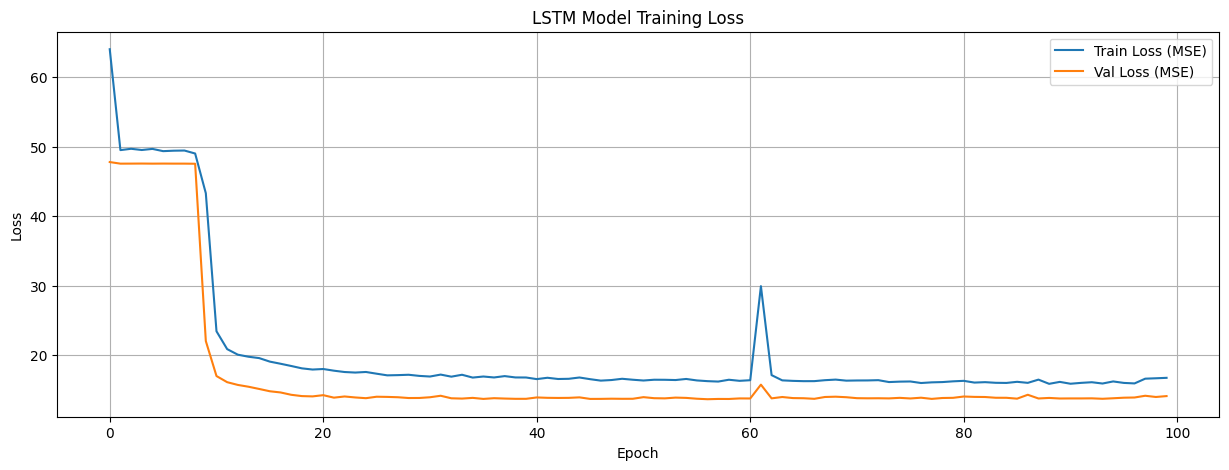

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(hist.history['loss'], label='Train Loss (MSE)')
plt.plot(hist.history['val_loss'], label='Val Loss (MSE)')

plt.title('LSTM Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# prediction on training and testing data
lstm_y_train_pred = lstm_model.predict(X_train_seq)
lstm_y_test_pred = lstm_model.predict(X_test_seq)

515/515 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


In [ ]:
# training and testing R2 score
lstm_r2_train = r2_score(y_train_seq, lstm_y_train_pred)
lstm_r2_test = r2_score(y_test_seq, lstm_y_test_pred)

print(f"Training R2 Score : {lstm_r2_train}")
print(f"Testing  R2 Score: {lstm_r2_test}")

Training R2 Score : 0.7028478652971598
Testing  R2 Score: 0.7008351834700781


In [ ]:
lstm_test_loss, lstm_test_mae = lstm_model.evaluate(X_test_seq, y_test_seq)
print(f"Test loss:{lstm_test_loss}")
print(f"Test MAE: {lstm_test_mae}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 14.3420 - mae: 2.7253
Test loss:14.110286712646484
Test MAE: 2.720151662826538


129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


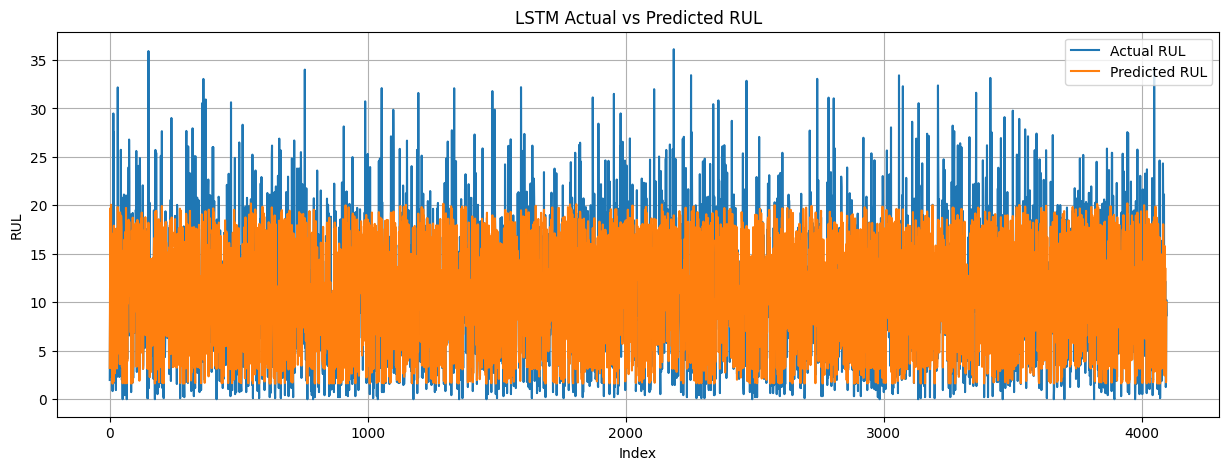

In [ ]:
# plot actual vs predicted values
lstm_y_test_pred = lstm_model.predict(X_test_seq).flatten()

plt.figure(figsize=(15,5))
plt.plot(y_test_seq, label='Actual RUL')
plt.plot(lstm_y_test_pred, label='Predicted RUL')
plt.title("LSTM Actual vs Predicted RUL")
plt.xlabel("Index")
plt.ylabel("RUL")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# save model
lstm_model.save("lstm_model.h5")
lstm_model.save("lstm_model.keras")

### **Create Hybrid Model**
**LSTM + LIGHTGBM**
* LSTM: To capture the temporal dependencies.
* LIGHTGBM: To make final RUL predication from LSTM extracted features.

In [14]:
# Create sequences
def convert_into_3D(X, y, window_size):
  X_seq, y_seq = [], []
  for i in range(len(X) - window_size):
    X_seq.append(X[i:i + window_size])
    y_seq.append(y.iloc[i + window_size-1])
  return np.array(X_seq), np.array(y_seq)

# Define window size as 1
window_size = 1
X_train_seq, y_train_seq = convert_into_3D(X_train_pca, y_train, window_size)
X_test_seq, y_test_seq = convert_into_3D(X_test_pca, y_test, window_size)

In [15]:
# LSTM for feature extraction
inputs = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
x = LSTM(64, return_sequences=True, dropout=0.2)(inputs)
x = LSTM(32, dropout=0.2)(x)
x = Dense(32, activation='relu')(x)
feature_extractor = Model(inputs, x)

feature_extractor.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,392 (122.62 KB)

 Trainable params: 31,392 (122.62 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Extract features using the LSTM
train_features = feature_extractor.predict(X_train_seq)
test_features = feature_extractor.predict(X_test_seq)

516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
# Flatten the features to 2D for RandomForest
train_features_2d = train_features.reshape(train_features.shape[0], -1)
test_features_2d = test_features.reshape(test_features.shape[0], -1)

In [18]:
# Train LGBMRegressor
from lightgbm import LGBMRegressor

model = LGBMRegressor(n_estimators=50, max_depth=5, random_state=42)

model.fit(train_features_2d, y_train_seq)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 16503, number of used features: 32
[LightGBM] [Info] Start training from score 10.961466
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMRegressor(max_depth=5, n_estimators=50, random_state=42)

In [19]:
# Predict on training set
y_train_pred = model.predict(train_features_2d)


# Predict on testing set
y_test_pred= model.predict(test_features_2d)

print(f"Training Prediction:{y_train_pred}")
print(f"Testig Prediction:{y_test_pred}")

Training Prediction:[ 2.66537558  7.31101856 20.83614337 ...  5.93375366  4.67226218
 18.61880403]
Testig Prediction:[18.469322   12.84528768  2.81129003 ...  1.69176246 10.1962691
 10.05879424]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [20]:
# Evaluate Training and Testing R2 score
HYBRID_TRAIN_R2 = r2_score(y_train_seq,y_train_pred)
HYBRID_TEST_R2 = r2_score(y_test_seq, y_test_pred)

print(f"Training R2 score:{HYBRID_TRAIN_R2}")
print(f"Testing R2 score:{HYBRID_TEST_R2}")



print("MSE:",MSE(y_test_seq, y_test_pred))
print("RMSE:",np.sqrt(MSE(y_test_seq, y_test_pred)))
print("MAE: ", MAE(y_test_seq, y_test_pred))

Training R2 score:0.743675785582157
Testing R2 score:0.7119553360987212
MSE: 13.607413862152725
RMSE: 3.688822828783286
MAE:  2.6281405489282412


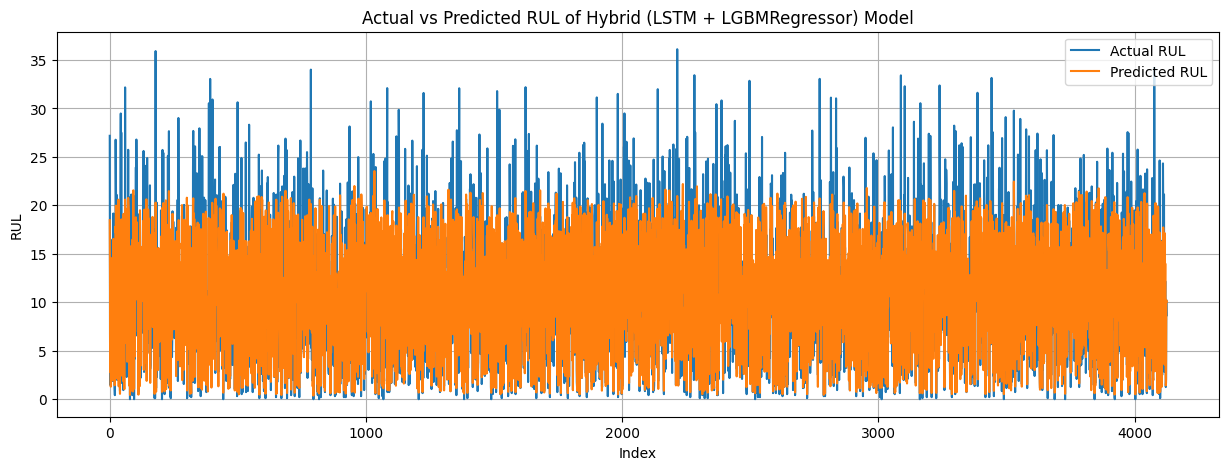

In [21]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_seq, label="Actual RUL")
plt.plot(y_test_pred, label="Predicted RUL")

plt.xlabel("Index")
plt.ylabel("RUL")
plt.title("Actual vs Predicted RUL of Hybrid (LSTM + LGBMRegressor) Model")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save the LSTM feature extractor model
feature_extractor.save("lstm_feature_extractor.keras")
feature_extractor.save("lstm_feature_extractor.h5")


joblib.dump(model, "hybrid_model.joblib")

['hybrid_model.joblib']

### Performance Camparison of all models

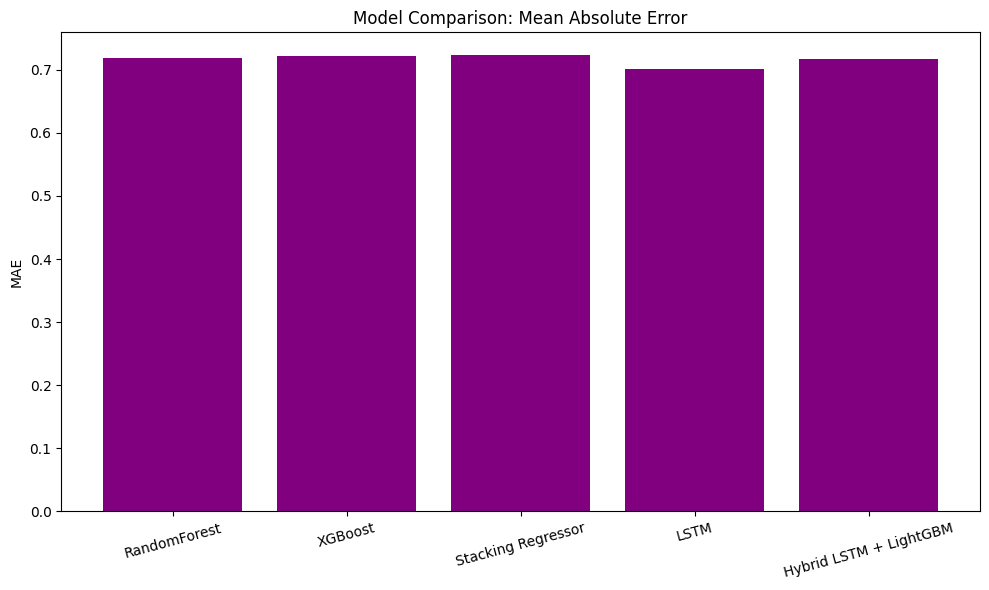

In [ ]:
models = ['RandomForest', 'XGBoost','Stacking Regressor', 'LSTM', 'Hybrid LSTM + LightGBM']
r2_scores = [0.7184, 0.7212, 0.7231, 0.7008,0.7165]


x = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(x, r2_scores, color='purple')
plt.ylabel('MAE')
plt.title('Model Comparison: R2 Scores')
plt.xticks(x, models, rotation=15)
plt.tight_layout()
plt.show()

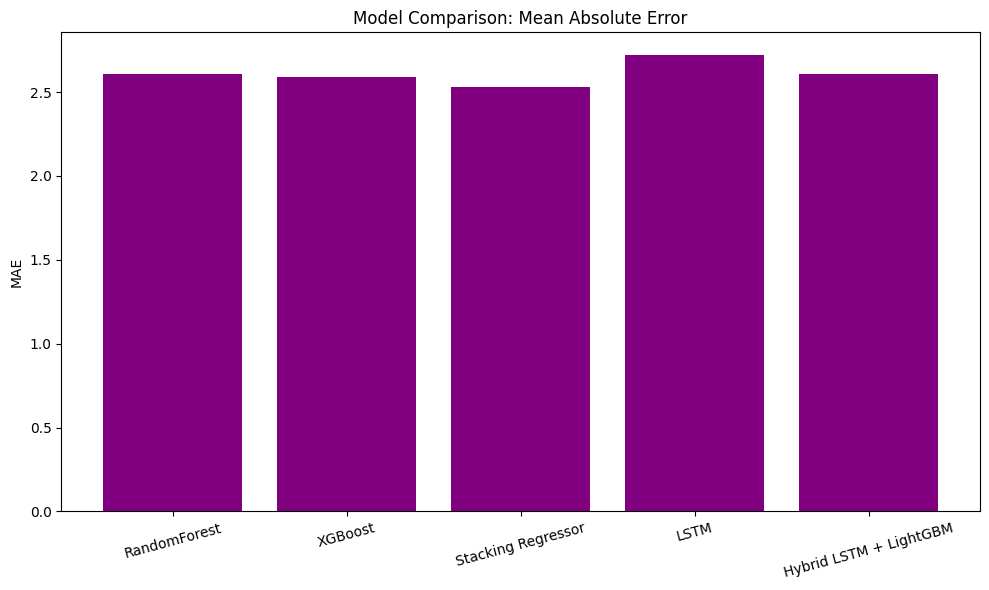

In [ ]:
models = ['RandomForest', 'XGBoost', 'Stacking Regressor', 'LSTM', 'Hybrid LSTM + LightGBM']
mae_scores = [2.6105, 2.5882, 2.5308, 2.7201, 2.605]

x = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(x, mae_scores, color='purple')
plt.ylabel('MAE')
plt.title('Model Comparison: Mean Absolute Error')
plt.xticks(x, models, rotation=15)
plt.tight_layout()
plt.show()

### Conclusion:

Based on all model performances the XGBoost, and Random Forest models performed well on both training and testing data with minimal error. These models achieved R² scores ranging between 0.71 and 0.72.

Other models like the LSTM also performed well on training and testing data achieving a testing R² score of 0.7008.

However, the Stacking Regressor and Hybrid LSTM + LightGBM model delivered best results with R2 score 72 percent.

In [1]:
import notebook
print(notebook.__version__)


7.2.2
